# Chart Pattern Recognition: Multi-Timeframe Analysis with Evolution Tracking and Regime Filtering

Vito Rizzuto


## Abstract

This project builds a computer vision system to detect chart patterns in financial markets. It Addresses three recurring problems that traders often face: high false-signal rates and delayed alerts in automated technical analysis, and uniform treatment of detections across market regimes. A YOLO26s object detector is trained on 1,024 labeled candlestick chart images covering 20 pattern classes, then enhanced with four post-detection layers: Platt-scaling confidence calibration, multi-timeframe confirmation filtering, pattern evolution tracking via progressive cropping, and regime-aware confidence scaling using empirical reliability statistics from Bulkowski's Encyclopedia of Chart Patterns. The system is benchmarked against classical baselines (logistic regression, random forest), a fine-tuned ResNet18, and an RT-DETR transformer detector. The main detector achieves a test mAP@50 of 0.273 on a highly imbalanced 20-class problem; the post-detection layers improve precision by up to +27.6 percentage points (multi-timeframe filtering) and +11.1 pp (regime filtering), with calibration reaching a Brier score of 0.0524. Results demonstrate that lightweight post-detection components can meaningfully reduce false signals even on small, imbalanced datasets where detector capacity is not the number one bottleneck.

## 1. Introduction

### 1.1 Problem & Motivation

Technical traders rely on chart patterns to identify potential trading opportunities. They look for repeating visual formations in price charts such as Head and Shoulders, Cup and Handle, and Triangle patterns, to name a few. Manually scanning charts for these patterns is time-consuming, subject to emotional bias, and does not scale across many instruments simultaneously. Existing automated tools partially address this through computer vision approaches, but in practice they suffer from three persistent problems. First, they typically analyze each timeframe in isolation, missing the cross-timeframe confirmation that experienced traders use to filter out false signals. Second, they only fire alerts after a pattern has fully formed, which often means the optimal entry point has already passed. Third, they treat all detections uniformly, ignoring the fact that pattern reliability varies substantially with market regime, for example, bullish reversal patterns are statistically more reliable in trending markets than in sideways consolidation [1].


### 1.2 Related Work

On the classical ML side, Kumbure et al. [4] surveyed machine learning techniques for stock market forecasting, covering Random Forest, SVM, and neural network approaches applied to numerical price features. Their survey establishes the historical reliance on engineered technical indicators, which sets the stage for more recent shifts toward deep learning architectures designed to capture the complex, non-linear relationships that traditional classifiers may struggle to extract.

The application of object detection to financial chart pattern recognition is a growing research area. Biroğul et al. [2] pioneered the use of YOLO for financial chart analysis, training a YOLO model on 2D candlestick charts from Borsa İstanbul (BIST) to recognize "Buy" and "Sell" objects based on visible trend formations, demonstrating that object detection is a viable approach for chart-based trading signals. More recently, Thakur and Kumar [7] applied a modified YOLOv8 to candlestick pattern detection on a simpler set of pattern classes. Rather than the 20-classes we are training on, they are specifically focusing on only four patterns, but are achieving an mAP@50 of 86.1%. Public implementations such as foduucom's YOLOv8 model on Hugging Face [3] have extended this line of work to real-time screen-capture detection with six pattern classes.

However, my knowledge, all existing work stops at single-image, single-pass detection. None of the above approaches address the three problems together, motivating this project: cross-timeframe confirmation to reduce false signals, early detection of forming patterns through temporal tracking, or regime-aware confidence scaling based on empirical pattern reliability statistics. The present work builds on the YOLO-based detection paradigm established by [2, 3, 7] and extends it with a four-layer post-detection pipeline that addresses these gaps.

### 1.3 My Approach

This project trains a YOLO26-based [8] pattern detector on a public Roboflow dataset of 1,450 labelled candlestick chart images covering 20 pattern classes, then layers four additional components on top: confidence calibration via Platt scaling [5], multi-timeframe confirmation, pattern evolution tracking via bounding-box trajectories, and regime-aware confidence scaling driven by empirical pattern-reliability statistics from Bulkowski's *Encyclopedia of Chart Patterns* [1]. The detector is benchmarked against two classical pixel-based baselines (logistic regression, random forest), a fine-tuned ResNet18 classifier, and an RT-DETR transformer-based detector [6] to fairly characterize what each modelling family does and does not contribute. The final YOLO26s detector achieves a test mAP@50 of 0.273 and mAP@50-95 of 0.155, the calibration component achieves a Brier score of 0.0524 (below the proposal target of 0.20), the multi-timeframe filter improves precision by between +19.5 and +27.6 percentage points depending on triplet structure, and the regime filter improves overall precision from 56.2% to 67.4%. Throughout the report, the limitations imposed by the dataset (small per-class sample sizes, no native temporal sequences, and no native market-regime labels) are explicitly acknowledged.

## 2. Methodology

### 2.1 Detection Backbone (YOLO26)

The core of the system is a YOLO26 object detector [8]. YOLO26 is the latest iteration of the Ultralytics YOLO family. The detector takes a 640×640 RGB chart image as input and outputs bounding boxes with class labels and confidence scores. Three model sizes were trained and compared (yolo26n, yolo26s, yolo26m); the small variant (yolo26s, 9.5M parameters) was selected as the final model based on a favourable accuracy-latency trade-off relative to the medium variant. The detector is initialized from COCO-pretrained weights and fine-tuned on the chart dataset.

### 2.2 Confidence Calibration

Raw confidence scores from object detectors are not, in general, well-calibrated probabilities, a detection with raw confidence 0.7 does not necessarily mean a 70% likelihood of being correct. To make downstream filtering decisions principled, raw scores are mapped to calibrated probabilities using Platt scaling [5]: a logistic regression is fit on the validation set with raw confidence as the input feature and per-detection correctness (defined as IoU ≥ 0.5 with a same-class ground-truth box) as the binary target. Calibration quality is evaluated using the Brier score and a reliability diagram comparing predicted vs actual probabilities across confidence bins.

### 2.3 Multi-Timeframe Filtering

In real trading, the same instrument is typically viewed at several timeframes (e.g. 5-minute, 15-minute, 1-hour), and a pattern that appears on multiple timeframes is considered a much stronger signal than one appearing on a single timeframe. This component implements a 2-of-3 confirmation rule: for a triplet of charts, a pattern class is *confirmed* only if it is independently detected by YOLO26s on at least two of the three charts. Because the dataset does not contain time-synchronized triplets of the same instrument, four triplet-construction strategies are used to characterize the rule's behaviour under different conditions: 3-of-3 triplets (all three images share a ground-truth pattern class), 2-of-3 triplets (two share a class, the third is from a different class), 1-of-3 triplets (all three from different classes), and a fully random baseline.

### 2.4 Pattern Evolution Tracking

Real chart patterns form gradually, and a system that only fires once a pattern is fully visible misses the early-entry advantage. This component simulates temporal pattern formation by progressively cropping each test chart at 60%, 75%, 90%, and 100% of its original width, earlier crops contain less of the most recent price action, simulating an earlier point in time. YOLO26s is run on each cropped version, and per-class trajectories of bounding-box area and confidence are tracked across the four "frames". For each pattern class detected in at least two frames, the trajectory is classified as evolving (both area and confidence grow by ≥15% from first to last frame), dissolving (either area or confidence drops by ≥15%), or stable (changes within the threshold). A growth ratio (last area / first area) is also reported per class as a continuous measure of formation progress.

### 2.5 Regime-Aware Filtering

Pattern reliability varies systematically with market regime: bullish patterns tend to play out more often in bull markets than in bear or sideways markets, and vice versa. This component scales each detection's confidence by two multiplicative factors: a per-pattern reliability weight derived from Bulkowski's empirically measured failure rates [1] (`reliability = 1 - failure_rate/100`), and a regime-alignment modifier (1.0 if the pattern's direction matches the current regime, 0.5 if it conflicts, 1.0 for neutral patterns; in sideways regimes only neutral patterns retain a weight of 1.0). The product `adjusted_conf = raw_conf × reliability × regime_modifier` is then thresholded as usual. Because the dataset does not include market-regime labels, regimes are assigned synthetically per test image using a fixed random seed, and the report explicitly frames this as a logic demonstration rather than a deployment evaluation.

### Project System Architecture

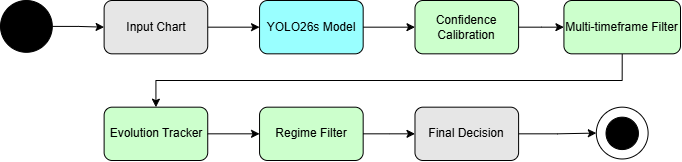

Figure 1: System Architecture

Grey boxes denote input/output stages, blue denotes the detection backbone, and green denotes the four post-detection components introduced in this work.

### YOLO26 Model Architecture Overview

Figure 2: YOLO26 architecture (Backbone, Neck, Head). Adapted from Figure 1 in [Hidayatullah & Tubagus, arXiv:2602.14582](https://arxiv.org/abs/2602.14582)

## 3. Experimental Setup



### 3.1 Dataset

The primary dataset is the public Roboflow Universe "chart-pattern-2" dataset (version 2) by user *ebtihel*, containing 1,450 RGB candlestick chart images annotated in YOLO format with bounding boxes over 20 distinct chart pattern classes. Images are pre-resized to 640×640 pixels via Roboflow's stretch-to-fit preprocessing, with no additional augmentation applied at the dataset level (augmentations are applied during YOLO training only). The dataset uses a fixed train/validation/test split of 1,024 / 285 / 141 images (≈71% / 20% / 10%). The 20 pattern classes are: Ascending-Triangle, Channel-down, Channel-up, Cup-and-handle, Descending-Triangle, Double-Bottom, Double-Top, Falling-Wedge, Head-Shoulders, Inverse-Head-Shoulders, Resistance-Emerging, Resistance-breakout, Rising-Wedge, Rounding-Bottom, Rounding-Top, Support-breakout, Triangle, Triple-Bottom, Triple-Top, and rectangle. Class distribution is highly imbalanced, with several classes having only 14–18 training images. This per-class scarcity (≈51 images per class on average) is the dataset's most significant limitation and is referenced repeatedly in the discussion of results.

A full breakdown of the per-class distribution across splits is provided at the end of section 3.


In [ ]:
# Mount Google Drive for persistent storage of model weights
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


This notebook requires a free Roboflow API key to download the dataset. Create one at roboflow.com/settings, then add it to Colab via Runtime --> Secrets with the name `roboflow_api_key`

In [ ]:
# Load Roboflow API key from Colab secrets
from google.colab import userdata
roboflow_api_key = userdata.get('roboflow_api_key')

In [ ]:
# Install dependencies
!pip install --upgrade ultralytics roboflow scikit-learn matplotlib pandas numpy opencv-python-headless

In [ ]:
# Imports
import os
import cv2
import numpy as np
import pandas as pd
import random
import torch
from roboflow import Roboflow
from sklearn.metrics import classification_report, accuracy_score, brier_score_loss
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from ultralytics import YOLO, RTDETR
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Following code taken from Roboflow docs to download a dataset off their platform [10]

In [ ]:
# Download the dataset
rf = Roboflow(api_key=roboflow_api_key)
project = rf.workspace("ebtihel").project("chart-pattern-2")
dataset = project.version(2).download("yolo26")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Chart-pattern-2-2 in yolo26:: 100%|██████████| 2905/2905 [00:00<00:00, 7070.80it/s]


### 3.2 Models & Hyperparameters

Three families of models are trained and compared:

**Object detectors (jointly localize and classify):**
- **YOLO26n / YOLO26s / YOLO26m**: Ultralytics YOLO26 detectors at three sizes (2.4M / 9.5M / 20.4M parameters). Initialized from COCO-pretrained weights. Trained with `epochs=200`, `patience=30` early stopping, `batch=16`, `imgsz=640`, `seed=42`. YOLO26s was selected as the production model based on its accuracy-latency trade-off.
- **RT-DETR-L**: Transformer-based real-time detector [6] with 32M parameters, trained with identical hyperparameters to YOLO via the Ultralytics interface for a fair architectural comparison.

**Pixel-based classical baselines** (image classification only, on flattened 64×64 RGB pixel vectors with `StandardScaler` normalization):
- **Logistic Regression**: tuned over `C ∈ {0.01, 0.1, 1, 10}` with `lbfgs` solver, `max_iter=2000`.
- **Random Forest**: tuned over `n_estimators ∈ {50, 100, 200, 300}` and `max_depth ∈ {None, 10, 20, 30}`.

**Deep classification baseline:**
- **ResNet18 (v1)**: ImageNet-pretrained, full fine-tuning on 224x224 RGB inputs, trained with cross-entropy loss, Adam (lr=1e-4, weight_decay=1e-4), early stopping on validation accuracy.
- **ResNet18 (v2)**: ImageNet-pretrained, backbone frozen, only the final classification head trained. Adam (lr=1e-3). This variant was added to test whether freezing the backbone could reduce overfitting and whether generic ImageNet features transfer to chart imagery.

For all baselines, hyperparameter search was performed on the validation set only; the test set was used exclusively for final reporting to prevent data leakage.


All training and evaluation hyperparameters are centralized here so that any change propagates consistently through the rest of the notebook.

In [ ]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Image / data
IMG_EXTS = ('.jpg', '.jpeg', '.png')
BASELINE_IMG_SIZE = 64                  # for flattened-pixel baselines
CNN_IMG_SIZE = 224                      # for ResNet

# Detection / evaluation
CONF_THRESHOLD = 0.25
IOU_THRESHOLD = 0.5
LOW_CONF_SWEEP = 0.01

# Pattern evolution
CROP_FRACTIONS = [0.6, 0.75, 0.9, 1.0]
GROWTH_THRESHOLD = 0.15

# Training Object Detection (YOLO + RT-DETR)
DETECTION_EPOCHS = 200
DETECTION_PATIENCE = 30
DETECTION_BATCH = 16
DETECTION_IMGSZ = 640

# Training CNN
CNN_EPOCHS = 30
CNN_PATIENCE = 5
CNN_LR = 1e-4
CNN_WEIGHT_DECAY = 1e-4
CNN_BATCH_SIZE = 32

# Paths
DRIVE_ROOT = '/content/drive/MyDrive/chart_patterns'
BEST_WEIGHTS = f'{DRIVE_ROOT}/yolo26s_run_x/weights/best.pt'
RTDETR_BEST_WEIGHTS = f'{DRIVE_ROOT}/rtdetr_run_x/weights/best.pt'

# Class names from data.yaml (used for reports and visualizations)
CLASS_NAMES = [
    "Ascending-Triangle", "Channel-down", "Channel-up", "Cup-and-handle",
    "Descending-Triangle", "Double-Bottom", "Double-Top", "Falling-Wedge",
    "Head-Shoulders", "Inverse-Head-Shoulders", "Resistance-Emerging",
    "Resistance-breakout", "Rising-Wedge", "Rounding-Bottom", "Rounding-Top",
    "Support-breakout", "Triangle", "Triple-Bottom", "Triple-Top", "rectangle"
]


In [ ]:
# Derived dataset paths
BASE = dataset.location
TRAIN_IMG_DIR = f"{BASE}/train/images"
TRAIN_LBL_DIR = f"{BASE}/train/labels"
VALID_IMG_DIR = f"{BASE}/valid/images"
VALID_LBL_DIR = f"{BASE}/valid/labels"
TEST_IMG_DIR  = f"{BASE}/test/images"
TEST_LBL_DIR  = f"{BASE}/test/labels"
DATA_YAML     = f"{BASE}/data.yaml"

SPLIT_DIRS = {
    "train": (TRAIN_IMG_DIR, TRAIN_LBL_DIR),
    "valid": (VALID_IMG_DIR, VALID_LBL_DIR),
    "test":  (TEST_IMG_DIR,  TEST_LBL_DIR),
}

Helper for reading YOLO-format .txt label files. Used throughout the notebook in three modes: first (one class per image, for the classification baselines), all (every class present in an image, for multi-timeframe filtering), and boxes (full bounding box coordinates, for IoU-based calibration).

In [ ]:
def label_path_for(img_file, label_dir):
    """
    Return the YOLO .txt label path corresponding to an image filename.

    Args:
        img_file (str): Image filename (e.g. 'img001.jpg').
        label_dir (str): Directory containing YOLO label files.

    Returns:
        str: Full path to the corresponding .txt label file.

    Example:
        >>> label_path_for('img001.jpg', '/data/labels')
        '/data/labels/img001.txt'
    """
    return os.path.join(label_dir, os.path.splitext(img_file)[0] + '.txt')

def parse_yolo_label(label_path, mode='first'):
    """
    Parse a YOLO label file.

    Args:
        label_path (str): Path to .txt label file.
        mode (str): 'first' returns the first class id (int) or None,
                    'all'   returns a set of class ids,
                    'boxes' returns list of (cls, cx, cy, w, h) tuples (normalized).

    Returns:
        Depends on mode. Returns None / empty set / empty list if file missing or empty.

    Example:
      >>> parse_yolo_label('/data/labels/img001.txt', mode='first')
      3
      >>> parse_yolo_label('/data/labels/img001.txt', mode='all')
      {3, 7}
      >>> parse_yolo_label('/data/labels/img001.txt', mode='boxes')
      [(3, 0.5, 0.5, 0.3, 0.4)]
    """
    if not os.path.exists(label_path):
        return None if mode == 'first' else (set() if mode == 'all' else [])

    with open(label_path, 'r') as f:
        lines = [ln.strip() for ln in f.readlines() if ln.strip()]

    if not lines:
        return None if mode == 'first' else (set() if mode == 'all' else [])

    if mode == 'first':
        return int(lines[0].split()[0])
    if mode == 'all':
        return {int(ln.split()[0]) for ln in lines}
    if mode == 'boxes':
        out = []
        for ln in lines:
            parts = ln.split()
            out.append((int(parts[0]), float(parts[1]), float(parts[2]),
                        float(parts[3]), float(parts[4])))
        return out
    raise ValueError(f"Unknown mode: {mode}")


### 3.3 Evaluation Metrics

Different model families are evaluated with metrics appropriate to their task:

- **Object detectors (YOLO, RT-DETR)** are evaluated using mean Average Precision (mAP) at IoU=0.50 (mAP@50) and averaged over IoU thresholds 0.50–0.95 in steps of 0.05 (mAP@50-95). mAP@50-95 is the primary detection metric reported throughout this work.
- **Classification baselines (LR, RF, ResNet18)** are evaluated using classification accuracy and per-class precision/recall/F1 via scikit-learn's `classification_report`.
- **Confidence calibration** is evaluated using the Brier score (mean squared error between predicted probabilities and binary outcomes) and a reliability diagram comparing predicted vs actual probabilities across binned confidence ranges.
- **Multi-timeframe filtering, evolution tracking, and regime filtering** are evaluated by comparing detection precision (correct detections / total detections) before and after applying each filter, and by reporting the change in confirmed detection count to characterize the precision-recall trade-off introduced by each filter.

The note on the precision/recall trade-off is important: all three filtering layers are designed to trade recall for precision, which is the appropriate trade-off for a trading system where false signals carry real cost. Reduced detection counts after filtering are expected and intentional.

The following summarizes the dataset splits and per-class distributions:

In [ ]:
# Total samples per split
print('\n--- Samples per split ---')
for split_name, (img_dir, _) in SPLIT_DIRS.items():
    num_images = len([f for f in os.listdir(img_dir) if f.lower().endswith(IMG_EXTS)])
    print(f"{split_name.capitalize()} set: {num_images} images")

# Samples per class per split
print('\n--- Samples per class per split ---')
class_counts_per_split = defaultdict(lambda: defaultdict(int))

for split_name, (img_dir, label_dir) in SPLIT_DIRS.items():
    for img_file in sorted(os.listdir(img_dir)):
        if not img_file.lower().endswith(IMG_EXTS):
            continue

        label_path = label_path_for(img_file, label_dir)
        classes_in_image = parse_yolo_label(label_path, mode='all')

        for cls_id in classes_in_image:
            class_counts_per_split[split_name][CLASS_NAMES[cls_id]] += 1

# Print the class counts
for split_name, class_counts in class_counts_per_split.items():
    print(f'\n{split_name.capitalize()} set class distribution:')
    if not class_counts:
        print('  No detections in this split for current configuration.')
        continue

    # Sort for consistent output
    sorted_class_counts = sorted(class_counts.items(), key=lambda item: item[1], reverse=True)
    for class_name, count in sorted_class_counts:
        print(f'  {class_name}: {count}')



--- Samples per split ---
Train set: 1024 images
Valid set: 285 images
Test set: 141 images

--- Samples per class per split ---

Train set class distribution:
  Head-Shoulders: 107
  Double-Bottom: 89
  Rounding-Bottom: 87
  Triple-Bottom: 85
  Inverse-Head-Shoulders: 85
  Channel-up: 82
  Channel-down: 81
  Double-Top: 74
  Triple-Top: 72
  Cup-and-handle: 71
  Ascending-Triangle: 69
  Support-breakout: 60
  Descending-Triangle: 59
  Rounding-Top: 58
  Resistance-Emerging: 58
  Rising-Wedge: 57
  rectangle: 56
  Triangle: 54
  Resistance-breakout: 54
  Falling-Wedge: 51

Valid set class distribution:
  Head-Shoulders: 32
  Channel-down: 29
  Double-Bottom: 26
  Double-Top: 24
  Rounding-Bottom: 23
  Triple-Bottom: 22
  Channel-up: 22
  Inverse-Head-Shoulders: 21
  Rounding-Top: 20
  Triple-Top: 19
  Falling-Wedge: 19
  rectangle: 18
  Ascending-Triangle: 16
  Descending-Triangle: 16
  Resistance-Emerging: 16
  Support-breakout: 16
  Triangle: 15
  Resistance-breakout: 15
  Rising-We

## 4. Experimental Results



### 4.1 Detection Models






Seven YOLO26 training runs were performed via the Ultralytics Python API [13] across three model sizes and several augmentation/regularization variants. The validation mAP results are summarized below; all runs used `epochs=200`, `patience=30`, `batch=16`, `imgsz=640`, `seed=42`.

| Run | Model    | Variant                          | Best Epoch | Val mAP@50 | Val mAP@50-95
|-----|----------|----------------------------------|------------|------------|---------------|
| 1   | YOLO26n  | baseline (epochs=100)            | 90        | 0.277      | 0.165         |
| 2   | YOLO26n  | epochs=200                       | 81         | 0.283      | 0.170         |
| 3   | YOLO26s  | baseline                         | 73         | 0.322      | 0.191         |
| 4   | YOLO26s  | fliplr=0.0 + freeze=10           | 55         | 0.300      | 0.174         |
| 5   | YOLO26s  | fliplr=0.0                       | 72         | 0.311      | 0.190         |
| 6   | YOLO26s  | fliplr=0.0 + mosaic=0.0          | 56         | 0.319      | 0.189         |
| 7   | YOLO26m  | baseline                         | 70         | 0.323      | 0.195         |

*to keep the notebook clean these various runs are not displayed - the data is stored in google drive and can be accessed here https://drive.google.com/drive/folders/1DKsSo6HbOYwQxOlM5NOnVVTlbVCm1_52?usp=drive_link*

Three observations from these experiments. First, scaling from yolo26n (2.4M params) --> yolo26s (9.5M) --> yolo26m (20.4M) yielded consistent but diminishing improvements (0.170 --> 0.191 --> 0.195 mAP@50-95), consistent with both model capacity and training data quantity being bottlenecks. Second, freezing the backbone (Run 4) hurt performance, indicating that COCO-pretrained early features still benefit from fine-tuning on the chart domain. Third, disabling horizontal flip and mosaic augmentations (Runs 5 and 6), which seemed like they should help since flipped chart patterns are not equivalent to the originals, produced no meaningful improvement, suggesting the default augmentations were not significantly damaging.

The following compares YOLO26m and YOLO26s on the held-out test set to finalize the model selection.

In [ ]:

yolo_m_path = f'{DRIVE_ROOT}/yolo26m_run1/weights/best.pt'
yolo_m_model = YOLO(yolo_m_path)

# Evaluating YOLO26m on held out test set
test_metrics = yolo_m_model.val(
    data=DATA_YAML,
    split="test",
    project=f'{DRIVE_ROOT}/predict',
    name='yolo26m_predict_run_test',
    verbose=False,
)

print(f"Test mAP@50:    {test_metrics.box.map50:.4f}")
print(f"Test mAP@50-95: {test_metrics.box.map:.4f}")


Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,364,872 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 863.2±200.1 MB/s, size: 28.4 KB)
val: Scanning /content/Chart-pattern-2-2/test/labels.cache... 141 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 141/141 34.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.4it/s 6.4s
                   all        141        219      0.334      0.285      0.272       0.16
Speed: 6.4ms preprocess, 26.1ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /content/drive/MyDrive/chart_patterns/predict/yolo26m_predict_run_test2
Test mAP@50:    0.2721
Test mAP@50-95: 0.1598


In [ ]:
yolo_s_path = f'{DRIVE_ROOT}/yolo26s_run1/weights/best.pt'
yolo_s_model = YOLO(yolo_s_path)

# Evalutating YOLO26s on held out test set
test_metrics = yolo_s_model.val(
    data=DATA_YAML,
    split="test",
    project=f'{DRIVE_ROOT}/predict',
    name='yolo26s_predict_run_test',
    verbose=False,
)

print(f"Test mAP@50:    {test_metrics.box.map50:.4f}")
print(f"Test mAP@50-95: {test_metrics.box.map:.4f}")


Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 122 layers, 9,472,920 parameters, 0 gradients, 20.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1224.8±304.4 MB/s, size: 26.2 KB)
val: Scanning /content/Chart-pattern-2-2/test/labels.cache... 141 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 141/141 53.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.8it/s 3.3s
                   all        141        219      0.334      0.314      0.272      0.155
Speed: 4.3ms preprocess, 9.9ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /content/drive/MyDrive/chart_patterns/predict/yolo26s_predict_run_test2
Test mAP@50:    0.2725
Test mAP@50-95: 0.1554


YOLO26s (Run 3) was selected as the model to use for this project. Although yolo26m achieved a slightly higher test mAP@50-95 (+0.0044), test inference latency on the T4 was ≈3× slower (26.1ms vs 9.9ms per image). For a real-time multi-timeframe system, it was decided that this latency cost was not worth the slight accuracy gain.

Now that the model is selected, the chosen one is trained again and will serve to produce the results.

In [ ]:
# Train YOLO26s on the chart pattern dataset
yolo_model = YOLO("yolo26s.pt")

results = yolo_model.train(
    data=DATA_YAML,
    epochs=DETECTION_EPOCHS,
    imgsz=DETECTION_IMGSZ,
    batch=DETECTION_BATCH,
    seed=SEED,
    patience=DETECTION_PATIENCE,
    project=DRIVE_ROOT,
    name="yolo26s_run_x"
)

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Chart-pattern-2-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26s_run_x, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

The selected production model (YOLO26s) is evaluated once on the held-out test set.

In [ ]:
# yolo_model = YOLO(BEST_WEIGHTS) (alternative to retraining - loading the already trained yolo model)

test_metrics = yolo_model.val(
    data=DATA_YAML,
    split="test",
    project=f'{DRIVE_ROOT}/predict',
    name='yolo26s_predict_run_x',
    verbose=False,
)

print(f"Test mAP@50:    {test_metrics.box.map50:.4f}")
print(f"Test mAP@50-95: {test_metrics.box.map:.4f}")


Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 122 layers, 9,472,920 parameters, 0 gradients, 20.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 14.9±7.3 MB/s, size: 28.8 KB)
val: Scanning /content/Chart-pattern-2-2/test/labels... 141 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 141/141 519.8it/s 0.3s
val: New cache created: /content/Chart-pattern-2-2/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.4it/s 3.8s
                   all        141        219      0.334      0.314      0.272      0.155
Speed: 5.0ms preprocess, 10.8ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /content/drive/MyDrive/chart_patterns/predict/yolo26s_predict_run_x
Test mAP@50:    0.2725
Test mAP@50-95: 0.1554


The test mAP is somewhat lower than the validation mAP, which is expected: the validation set was used during training for early stopping and best-checkpoint selection, so val numbers are a tiny bit optimistic. The test set is small (141 images, with one class having as low as 2 instances), so per-class metrics are noisy.

The per-class breakdown is charted below.

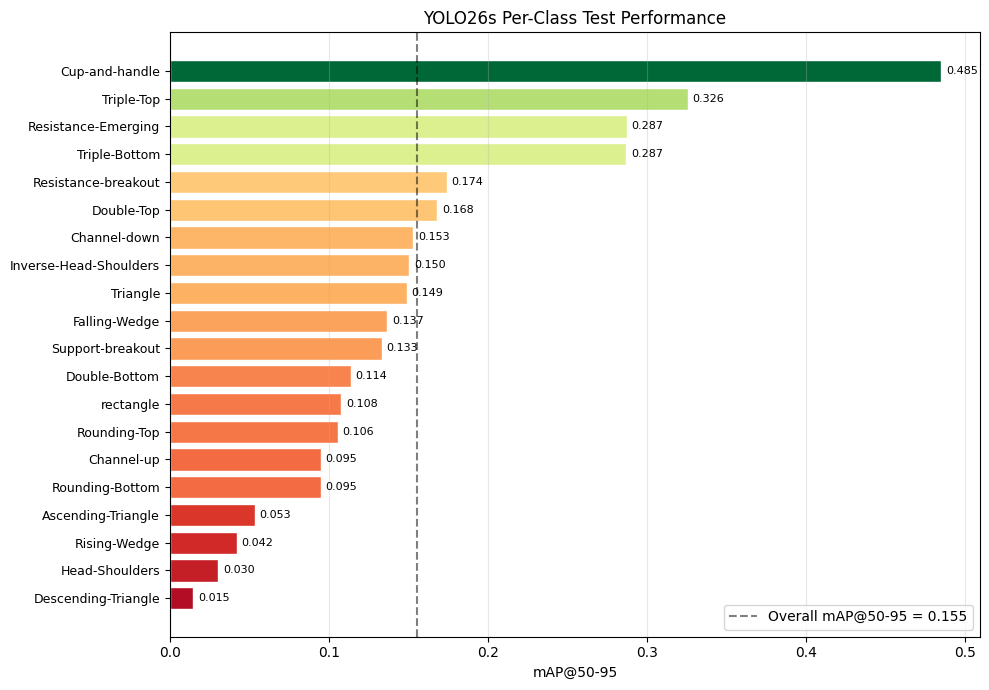

In [ ]:
# Per-class test mAP@50-95 bar chart for YOLO26s
class_names = test_metrics.names  # dict {id: name}
per_class_map = test_metrics.box.maps  # array of per-class mAP@50-95

# Sort by mAP descending for readability
sorted_idx = np.argsort(per_class_map)[::-1]
sorted_names = [class_names[i] for i in sorted_idx]
sorted_maps = per_class_map[sorted_idx]

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.RdYlGn(sorted_maps / max(sorted_maps.max(), 0.01))  # green=high, red=low
bars = ax.barh(range(len(sorted_names)), sorted_maps, color=colors, edgecolor='white')
ax.set_yticks(range(len(sorted_names)))
ax.set_yticklabels(sorted_names, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('mAP@50-95')
ax.set_title('YOLO26s Per-Class Test Performance')
ax.axvline(x=test_metrics.box.map, color='black', linestyle='--', alpha=0.5,
           label=f'Overall mAP@50-95 = {test_metrics.box.map:.3f}')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

# Annotate values on bars
for i, (bar, val) in enumerate(zip(bars, sorted_maps)):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/yolo_perclass_map.png', dpi=150)
plt.show()


For comparison against YOLO's CNN backbone, RT-DETR-L (a 32M params, transformer-based detector) is trained on the same dataset with the same hyperparameters.

In [ ]:
# RT-DETR training (Transformer-based detector, comparison to YOLO's CNN)
rtdetr_model = RTDETR("rtdetr-l.pt")

rtdetr_results = rtdetr_model.train(
    data=DATA_YAML,
    epochs=DETECTION_EPOCHS,
    imgsz=DETECTION_IMGSZ,
    batch=DETECTION_BATCH,
    seed=SEED,
    patience=DETECTION_PATIENCE,
    project="/content/drive/MyDrive/chart_patterns",
    name="rtdetr_run_x"
)

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Chart-pattern-2-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rtdetr_run_x, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


      1/200      12.5G      1.188      12.82     0.9442         48        640: 100% ━━━━━━━━━━━━ 64/64 1.3s/it 1:24
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.1s/it 9.9s
                   all        285        444   0.000422     0.0916    0.00132   0.000678

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


      2/200      12.7G     0.6877      1.957     0.4825         40        640: 100% ━━━━━━━━━━━━ 64/64 1.2s/it 1:16
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.7it/s 5.4s
                   all        285        444    0.00461      0.183    0.00301   0.000913

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


...

     64/200      12.5G     0.2988     0.7211     0.2024         44        640: 100% ━━━━━━━━━━━━ 64/64 1.2s/it 1:16
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.6it/s 5.5s
                   all        285        444      0.342      0.308      0.268      0.171

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


     65/200      12.7G     0.3046     0.7151     0.2158         33        640: 100% ━━━━━━━━━━━━ 64/64 1.2s/it 1:16
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.7it/s 5.3s
                   all        285        444      0.341      0.405      0.308      0.191

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


     66/200      12.6G     0.3074     0.6947     0.2135         44        640: 100% ━━━━━━━━━━━━ 64/64 1.2s/it 1:15
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.7it/s 5.4s
                   all        285        444      0.374      0.328      0.281      0.175
EarlyStopping: Training stopped early as no improvement observed in last 30 epochs. Best results observed at epoch 36, best model saved as best.pt.
To update EarlyStopping(patience=30) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

66 epochs completed in 1.747 hours.
Optimizer stripped from /content/drive/MyDrive/chart_patterns/rtdetr_run_x/weights/last.pt, 66.3MB
Optimizer stripped from /content/drive/MyDrive/chart_patterns/rtdetr_run_x/weights/best.pt, 66.3MB

Validating /content/drive/MyDrive/chart_patterns/rtdetr_run_x/weights/best.pt...
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14

The RT-DETR model is evaluated once on the held-out test set.

In [ ]:
# rtdetr_model = RTDETR(RTDETR_BEST_WEIGHTS) (alternative to retraining - loading the already trained RT-DETR model)

rtdetr_test_metrics = rtdetr_model.val(
    data=DATA_YAML,
    split="test",
    project='/content/drive/MyDrive/chart_patterns/predict/',
    name='rtdetr_predict_run_x',
    verbose=False,
)

print(f"RT-DETR Test mAP@50:    {rtdetr_test_metrics.box.map50:.4f}")
print(f"RT-DETR Test mAP@50-95: {rtdetr_test_metrics.box.map:.4f}")


Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 32,024,840 parameters, 0 gradients, 103.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 19.8±5.0 MB/s, size: 30.3 KB)
val: Scanning /content/Chart-pattern-2-2/test/labels.cache... 141 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 141/141 59.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.3it/s 6.9s
                   all        141        219      0.462      0.327      0.316      0.189
Speed: 3.2ms preprocess, 40.0ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/drive/MyDrive/chart_patterns/predict/rtdetr_predict_run_x
RT-DETR Test mAP@50:    0.3162
RT-DETR Test mAP@50-95: 0.1894


| Detector       | Params | Val mAP@50 | Val mAP@50-95 | Test mAP@50 | Test mAP@50-95 | Test Inference (T4) |
|----------------|--------|------------|---------------|-------------|----------------|----------------|
| **YOLO26s**    | 9.5M   | 0.319      | 0.188         | 0.2725       | 0.1554          | 10.8 ms          |
| RT-DETR-L      | 32M    | 0.343      | 0.213         | 0.3162       | 0.1894          | 40.0 ms         |

RT-DETR had the best validation mAP@50-95 (0.213), beating YOLO26s by +0.025 despite using ~3× more parameters and being ~4× slower at inference. On the held-out test set, RT-DETR also led (0.1894 vs 0.1554 for YOLO26s), confirming that this wasn't just due to validation-set overfitting. However, the gains are small, which reinforces the data-bottleneck hypothesis: even a completely different architecture (transformer vs CNN) only squeezes out a marginal improvement from this amount of training data.

### 4.2 Baselines Comparison



To contextualize YOLO's detection performance and justify the choice of object detection over just classification, four baseline models were trained: two classical pixel-based classifiers (logistic regression, random forest) and two ResNet18 variants. All baselines process the image as a whole and predict a single class label per image; none perform localization.

| Model                   | Type                          | Best Hyperparameters             | Test Accuracy |
|-------------------------|-------------------------------|----------------------------------|---------------|
| Logistic Regression     | Linear classifier             | C=0.01                           | 0.331         |
| Random Forest           | Tree ensemble                 | n_estimators=100, max_depth=20   | 0.281         |
| ResNet18 (v1, full FT)  | Deep CNN, full fine-tune       | early-stopped at epoch 20        | **0.403**     |
| ResNet18 (v2, frozen)   | Deep CNN, frozen backbone      | early-stopped at epoch 26        | 0.295         |

Two findings. First, the classical pixel-based baselines hover around 28–33% test accuracy. Hyperparameter tuning produced only modest gains, confirming that the bottleneck for these models is the feature representation (flattened raw pixels), not the classifier. Second, ResNet18 with full fine-tuning and regularization techniques achieved the best baseline (40.29%), but this still represents a low ceiling for classification-only approaches on this dataset. ResNet18 v2 (frozen backbone) underperformed v1 by over 10 pp, indicating that ImageNet features alone, without fine-tuning, aren't enough for chart pattern classification.

The comparison between baselines and YOLO is not strictly apples-to-apples: baselines perform image-level classification only (1-of-20 class prediction), while YOLO performs joint detection and classification, which is a harder task scored by the much stricter mAP@50-95 metric. The point of including the baselines is therefore not to compete with YOLO on the same metric, but to show that pixel-based or classification-only approaches cannot supply the spatial bounding-box information required by the downstream pipeline (multi-timeframe filtering, evolution tracking).


The method below serves to load the images as flattened pixels for the classical baselines

In [ ]:
def load_images_and_labels(img_dir, label_dir, img_size=BASELINE_IMG_SIZE):
    """
    Load images as flattened pixel vectors and extract class labels
    from YOLO annotation files.

    Args:
        img_dir (str): Path to image directory.
        label_dir (str): Path to YOLO label directory.
        img_size (int): Resize dimension (img_size x img_size).

    Returns:
        X (np.ndarray): Flattened image array of shape (n_samples, img_size*img_size*3).
        y (list): List of class labels (integers).

    Example:
      >>> X, y = load_images_and_labels('/data/train/images', '/data/train/labels')
      >>> X.shape
      (1024, 12288)
      >>> len(y)
      1024
    """
    X, y = [], []
    for img_file in sorted(os.listdir(img_dir)):
        if not img_file.lower().endswith(IMG_EXTS):
            continue
        cls = parse_yolo_label(label_path_for(img_file, label_dir), mode='first')
        if cls is None:
            continue
        img = cv2.imread(os.path.join(img_dir, img_file))
        img = cv2.resize(img, (img_size, img_size))
        X.append(img.flatten())
        y.append(cls)
    return np.array(X), y

# Load data
X_train, y_train = load_images_and_labels(TRAIN_IMG_DIR, TRAIN_LBL_DIR)
X_val, y_val = load_images_and_labels(VALID_IMG_DIR, VALID_LBL_DIR)
X_test, y_test = load_images_and_labels(TEST_IMG_DIR, TEST_LBL_DIR)

# Standardize features (mean 0, std 1) for well-conditioned optimization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

Logistic Regression [14] with Hyperparameter Tuning.

In [ ]:
print("=== Logistic Regression ===")
best_lr_acc = 0
for C in [0.01, 0.1, 1, 10]:
    lr = LogisticRegression(C=C, solver='lbfgs', max_iter=2000, random_state=SEED)
    lr.fit(X_train, y_train)
    val_acc = accuracy_score(y_val, lr.predict(X_val))
    if val_acc > best_lr_acc:
        best_lr_acc = val_acc
        best_lr_params = {'C': C}
        best_lr_model = lr
    print(f"C={C}, Val acc: {val_acc:.4f}")

print(f"\nBest params: {best_lr_params}, Val accuracy: {best_lr_acc:.4f}")
lr_test_acc = accuracy_score(y_test, best_lr_model.predict(X_test))
print(f"Test accuracy: {lr_test_acc:.4f}")
print(classification_report(y_test, best_lr_model.predict(X_test)))


=== Logistic Regression ===


lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


C=0.01, Val acc: 0.3099
C=0.1, Val acc: 0.3063
C=1, Val acc: 0.2923
C=10, Val acc: 0.2958

Best params: {'C': 0.01}, Val accuracy: 0.3099
Test accuracy: 0.3309
              precision    recall  f1-score   support

           0       1.00      0.20      0.33         5
           1       0.50      0.11      0.18         9
           2       0.60      0.43      0.50         7
           3       0.80      0.50      0.62         8
           4       0.00      0.00      0.00         3
           5       0.33      0.15      0.21        13
           6       0.14      0.14      0.14         7
           7       0.00      0.00      0.00         4
           8       0.28      0.38      0.32        13
           9       0.20      0.22      0.21         9
          10       1.00      0.40      0.57         5
          11       0.44      1.00      0.61         7
          12       0.00      0.00      0.00         5
          13       0.13      0.38      0.19         8
          14       0.25      

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


Random Forest [15] with Hyperparameter Tuning.

In [ ]:
print("=== Random Forest ===")
best_rf_acc = 0
for n_est in [50, 100, 200, 300]:
    for max_depth in [None, 10, 20, 30]:
        rf = RandomForestClassifier(n_estimators=n_est, max_depth=max_depth, random_state=SEED, n_jobs=-1)
        rf.fit(X_train, y_train)
        val_acc = accuracy_score(y_val, rf.predict(X_val))
        if val_acc > best_rf_acc:
            best_rf_acc = val_acc
            best_rf_params = {'n_estimators': n_est, 'max_depth': max_depth}
            best_rf_model = rf
        print(f"n_est={n_est}, depth={max_depth}, Val acc: {val_acc:.4f}")

print(f"\nBest params: {best_rf_params}, Val accuracy: {best_rf_acc:.4f}")
rf_test_acc = accuracy_score(y_test, best_rf_model.predict(X_test))
print(f"Test accuracy: {rf_test_acc:.4f}")
print(classification_report(y_test, best_rf_model.predict(X_test)))


=== Random Forest ===
n_est=50, depth=None, Val acc: 0.3028
n_est=50, depth=10, Val acc: 0.3275
n_est=50, depth=20, Val acc: 0.3169
n_est=50, depth=30, Val acc: 0.3169
n_est=100, depth=None, Val acc: 0.3204
n_est=100, depth=10, Val acc: 0.3345
n_est=100, depth=20, Val acc: 0.3451
n_est=100, depth=30, Val acc: 0.3169
n_est=200, depth=None, Val acc: 0.3275
n_est=200, depth=10, Val acc: 0.3310
n_est=200, depth=20, Val acc: 0.3415
n_est=200, depth=30, Val acc: 0.3451
n_est=300, depth=None, Val acc: 0.3415
n_est=300, depth=10, Val acc: 0.3415
n_est=300, depth=20, Val acc: 0.3451
n_est=300, depth=30, Val acc: 0.3380

Best params: {'n_estimators': 100, 'max_depth': 20}, Val accuracy: 0.3451
Test accuracy: 0.2806
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.50      0.22      0.31         9
           2       0.40      0.29      0.33         7
           3       0.57      0.50      0.53         8
           4  

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


For the ResNet18 baselines, images are loaded as actual RGB tensors (not flattened pixels) at 224×224 (the input size ResNet was pretrained on). Each image gets one label (the first ground-truth box's class) to keep the comparison fair against the classical baselines above.

The Dataset inheritance used in ChartPatternDataset and the DataLoader setup in make_cnn_loaders follow the PyTorch data loading tutorial [16].

In [ ]:
class ChartPatternDataset(Dataset):
    """
    PyTorch Dataset for chart pattern classification.

    Loads images from a YOLO-format directory and assigns one label per
    image (the class of the first bounding box in the label file).

    Args:
        img_dir (str): Path to image directory.
        label_dir (str): Path to YOLO label directory.
        transform (callable, optional): Torchvision transform applied to each image.

    Returns:
        ChartPatternDataset: A Dataset instance compatible with PyTorch DataLoader.

    Example:
        >>> dataset = ChartPatternDataset(TRAIN_IMG_DIR, TRAIN_LBL_DIR, transform=cnn_transform)
        >>> img_tensor, label = dataset[0]
        >>> img_tensor.shape
        torch.Size([3, 224, 224])
    """

    def __init__(self, img_dir, label_dir, transform=None):
        """
        Initialize the dataset by scanning img_dir for valid images and
        pairing each with its class label from the corresponding YOLO label file.

        Args:
            img_dir (str): Path to image directory.
            label_dir (str): Path to YOLO label directory.
            transform (callable, optional): Torchvision transform applied to each image.

        Returns:
            None

        Example:
            >>> dataset = ChartPatternDataset(TRAIN_IMG_DIR, TRAIN_LBL_DIR, transform=cnn_transform)
            >>> len(dataset)
            1024
        """
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transform = transform
        self.samples = []

        for fname in sorted(os.listdir(img_dir)):
            if not fname.lower().endswith(IMG_EXTS):
                continue
            cls = parse_yolo_label(label_path_for(fname, label_dir), mode='first')
            if cls is None:
                continue
            self.samples.append((os.path.join(img_dir, fname), cls))

    def __len__(self):
        """
        Return the number of valid image-label pairs in the dataset.

        Args:
            None

        Returns:
            int: Number of samples.

        Example:
            >>> dataset = ChartPatternDataset(TRAIN_IMG_DIR, TRAIN_LBL_DIR)
            >>> len(dataset)
            1024
        """
        return len(self.samples)

    def __getitem__(self, idx):
      """
      Return (image_tensor, class_label) for the sample at index idx.

      Args:
          idx (int): Sample index.

      Returns:
          tuple: (torch.Tensor, int) image tensor and class ID.

      Example:
        >>> dataset = ChartPatternDataset(TRAIN_IMG_DIR, TRAIN_LBL_DIR, transform=cnn_transform)
        >>> img_tensor, label = dataset[0]
        >>> img_tensor.shape
        torch.Size([3, 224, 224])
      """
      path, label = self.samples[idx]
      img = Image.open(path).convert("RGB")
      if self.transform:
          img = self.transform(img)
      return img, label

In [ ]:
def make_cnn_loaders(transform, batch_size):
    """
    Build train/valid/test DataLoaders for the chart-pattern dataset.

    Args:
        transform (callable): Torchvision transform applied to each image.
        batch_size (int): Number of samples per batch.

    Returns:
        tuple: (splits dict, loaders dict) where keys are 'train', 'valid', 'test'.

    Example:
        >>> splits, loaders = make_cnn_loaders(cnn_transform, batch_size=32)
        >>> len(splits['train'])
        1024
    """
    splits = {
        name: ChartPatternDataset(img_dir, lbl_dir, transform=transform)
        for name, (img_dir, lbl_dir) in SPLIT_DIRS.items()
    }
    loaders = {
        name: DataLoader(ds, batch_size=batch_size,
                         shuffle=(name == "train"), num_workers=2)
        for name, ds in splits.items()
    }
    return splits, loaders


def build_resnet18(num_classes, device, freeze_backbone=False):
    """
    Load pretrained ResNet18 with a new final layer for `num_classes`.

    Args:
        num_classes (int): Number of output classes.
        device: torch device.
        freeze_backbone (bool): If True, freeze all layers except the final
            classifier. Recommended for small datasets to prevent overfitting.

    Returns:
      torch.nn.Module: ResNet18 model moved to `device`.

    Example:
      >>> model = build_resnet18(num_classes=20, device=torch.device('cuda'))
    """
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    model.fc = nn.Sequential(
      nn.Dropout(0.3),
      nn.Linear(model.fc.in_features, num_classes)
      )
    return model.to(device)


def evaluate_classifier(model, loader, device):
    """
    Return accuracy of `model` on a given DataLoader.

    Args:
        model (torch.nn.Module): Trained classification model.
        loader (DataLoader): DataLoader for the split to evaluate.
        device: torch device (cpu or cuda).

    Returns:
        float: Classification accuracy between 0 and 1.

    Example:
        >>> acc = evaluate_classifier(model, loaders['test'], device)
        >>> print(f"Test accuracy: {acc:.4f}")
    """
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total


def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    Run one training epoch and return average loss.

    Args:
        model (torch.nn.Module): Model to train.
        loader (DataLoader): Training DataLoader.
        criterion: Loss function (e.g. nn.CrossEntropyLoss()).
        optimizer: Optimizer (e.g. torch.optim.AdamW).
        device: torch device.

    Returns:
        float: Average loss over all batches in the epoch.

    Example:
        >>> loss = train_one_epoch(model, loaders['train'], criterion, optimizer, device)
    """
    model.train()
    total_loss, n_batches = 0.0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        n_batches += 1
    return total_loss / max(n_batches, 1)


def train_with_early_stopping(model, loaders, criterion, optimizer, device,
                              epochs, patience):
    """
    Train `model` with early stopping on validation accuracy.

    Args:
      model (torch.nn.Module): Model to train.
      loaders (dict): Dict with keys 'train' and 'valid' mapping to DataLoaders.
      criterion: Loss function.
      optimizer: Optimizer.
      device: torch device.
      epochs (int): Maximum number of training epochs.
      patience (int): Number of epochs with no improvement before stopping.

    Returns:
        (best_val_acc, best_state_dict)

    Example:
        >>> best_val_acc, best_state = train_with_early_stopping(
        ...     model, loaders, criterion, optimizer, device, epochs=30, patience=5)
    """
    best_val_acc = 0.0
    best_state = None
    no_improve = 0

    for epoch in range(epochs):
        train_loss = train_one_epoch(model, loaders["train"], criterion, optimizer, device)
        val_acc = evaluate_classifier(model, loaders["valid"], device)
        print(f"Epoch {epoch+1}: loss={train_loss:.4f}, val_acc={val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    return best_val_acc, best_state

v1: Full fine-tuning. All ResNet18 [17] layers are trainable, with Adam at lr=1e-4, weight_decay=1e-4, and dropout (0.3) before the final classification layer. This lets the network adapt all features to chart imagery, but with only ~1024 training images there is meaningful overfitting risk.

Initially the model was trained without dropout or weight decay, but it was overfitting so both were added as regularization.

In [ ]:
print("=== ResNet18 (pretrained) ===")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
# Standard ImageNet preprocessing, no augmentation (charts are orientation-sensitive)
cnn_transform = transforms.Compose([
    transforms.Resize((CNN_IMG_SIZE, CNN_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

cnn_splits, cnn_loaders = make_cnn_loaders(cnn_transform, CNN_BATCH_SIZE)
print(f"Train: {len(cnn_splits['train'])}, "
      f"Val: {len(cnn_splits['valid'])}, "
      f"Test: {len(cnn_splits['test'])}")

num_classes = len(set(label for _, label in cnn_splits["train"].samples))
cnn_v1 = build_resnet18(num_classes, device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_v1.parameters(), lr=CNN_LR, weight_decay=CNN_WEIGHT_DECAY)

best_val_acc, best_state = train_with_early_stopping(
    cnn_v1, cnn_loaders, criterion, optimizer, device,
    epochs=CNN_EPOCHS, patience=CNN_PATIENCE,
)

cnn_v1.load_state_dict(best_state)
cnn_v1_test_acc = evaluate_classifier(cnn_v1, cnn_loaders["test"], device)
print(f"\nBest val accuracy: {best_val_acc:.4f}")
print(f"Test accuracy:     {cnn_v1_test_acc:.4f}")

=== ResNet18 (pretrained) ===
Device: cuda
Train: 1017, Val: 284, Test: 139
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s]


Epoch 1: loss=2.5996, val_acc=0.3134
Epoch 2: loss=1.7450, val_acc=0.3732
Epoch 3: loss=1.2388, val_acc=0.4085
Epoch 4: loss=0.8140, val_acc=0.4049
Epoch 5: loss=0.4572, val_acc=0.3908
Epoch 6: loss=0.2278, val_acc=0.4155
Epoch 7: loss=0.1335, val_acc=0.3908
Epoch 8: loss=0.0898, val_acc=0.4049
Epoch 9: loss=0.0525, val_acc=0.4190
Epoch 10: loss=0.0394, val_acc=0.4331
Epoch 11: loss=0.0300, val_acc=0.4331
Epoch 12: loss=0.0268, val_acc=0.4261
Epoch 13: loss=0.0235, val_acc=0.4225
Epoch 14: loss=0.0193, val_acc=0.4261
Epoch 15: loss=0.0157, val_acc=0.4401
Epoch 16: loss=0.0154, val_acc=0.4296
Epoch 17: loss=0.0130, val_acc=0.4155
Epoch 18: loss=0.0111, val_acc=0.4366
Epoch 19: loss=0.0100, val_acc=0.4261
Epoch 20: loss=0.0098, val_acc=0.4190
Early stopping at epoch 20

Best val accuracy: 0.4401
Test accuracy:     0.4029


=== ResNet18 v1 Classification Report (Test Set) ===
                        precision    recall  f1-score   support

    Ascending-Triangle       0.67      0.40      0.50         5
          Channel-down       0.50      0.44      0.47         9
            Channel-up       0.29      0.29      0.29         7
        Cup-and-handle       0.86      0.75      0.80         8
   Descending-Triangle       0.00      0.00      0.00         3
         Double-Bottom       0.67      0.15      0.25        13
            Double-Top       0.23      0.43      0.30         7
         Falling-Wedge       0.67      0.50      0.57         4
        Head-Shoulders       0.35      0.54      0.42        13
Inverse-Head-Shoulders       0.33      0.44      0.38         9
   Resistance-Emerging       0.67      0.40      0.50         5
   Resistance-breakout       0.50      0.57      0.53         7
          Rising-Wedge       0.00      0.00      0.00         5
       Rounding-Bottom       0.09      0.12      0

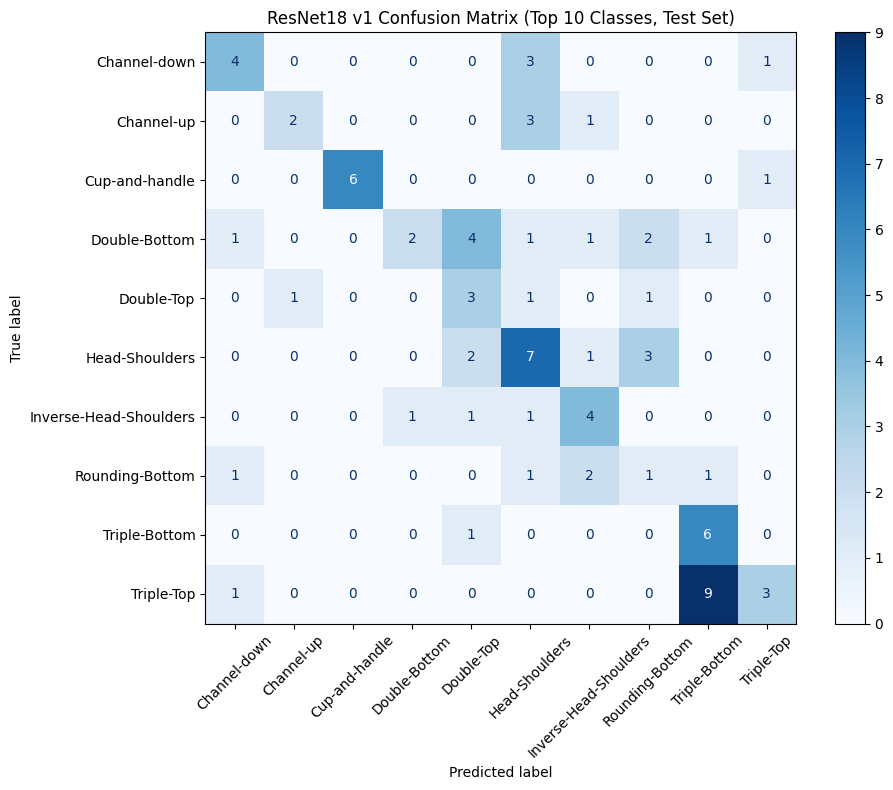

In [ ]:
# Classification report and confusion matrix for ResNet18 v1 (best baseline)
cnn_v1.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in cnn_loaders['test']:
        imgs = imgs.to(device)
        preds = cnn_v1(imgs).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Get class names from the dataset
unique_labels = sorted(set(all_labels))
target_names = [CLASS_NAMES[i] if i < len(CLASS_NAMES) else str(i) for i in unique_labels]

print("=== ResNet18 v1 Classification Report (Test Set) ===")
print(classification_report(all_labels, all_preds,
                            labels=unique_labels,
                            target_names=target_names,
                            zero_division=0))

# Confusion matrix (only top-10 most frequent classes to keep it readable)
label_counts = Counter(all_labels)
top_classes = [cls for cls, _ in label_counts.most_common(10)]
top_mask = [i for i, l in enumerate(all_labels) if l in top_classes]
top_labels = [all_labels[i] for i in top_mask]
top_preds = [all_preds[i] for i in top_mask]
top_names = [CLASS_NAMES[c] if c < len(CLASS_NAMES) else str(c) for c in sorted(set(top_classes))]

fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(top_labels, top_preds, labels=sorted(top_classes))
disp = ConfusionMatrixDisplay(cm, display_labels=top_names)
disp.plot(ax=ax, cmap='Blues', values_format='d', xticks_rotation=45)
ax.set_title('ResNet18 v1 Confusion Matrix (Top 10 Classes, Test Set)')
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/resnet_confusion_matrix.png', dpi=150)
plt.show()


v2: Frozen backbone. Only the final classifier layer is trained, with a higher learning rate (1e-3) since there are much less trainable parameters. Compares directly to v1 to test whether full fine-tuning helps or hurts on a small dataset.


In [ ]:
print("=== ResNet18 v2 (frozen backbone) ===")
cnn_v2 = build_resnet18(num_classes, device, freeze_backbone=True)

trainable_params = [p for p in cnn_v2.parameters() if p.requires_grad]
n_trainable = sum(p.numel() for p in trainable_params)
n_total = sum(p.numel() for p in cnn_v2.parameters())
print(f"Trainable parameters: {n_trainable:,} / {n_total:,} "
      f"({100 * n_trainable / n_total:.2f}%)")

criterion_v2 = nn.CrossEntropyLoss()
optimizer_v2 = torch.optim.Adam(trainable_params, lr=1e-3)  # higher LR than v1 since fewer params

best_val_acc_v2, best_state_v2 = train_with_early_stopping(
    cnn_v2, cnn_loaders, criterion_v2, optimizer_v2, device,
    epochs=CNN_EPOCHS, patience=CNN_PATIENCE,
)

cnn_v2.load_state_dict(best_state_v2)
cnn_v2_test_acc = evaluate_classifier(cnn_v2, cnn_loaders["test"], device)
print(f"\n[v2] Best val accuracy: {best_val_acc_v2:.4f}")
print(f"[v2] Test accuracy:     {cnn_v2_test_acc:.4f}")
print(f"\nImprovement over v1: {(cnn_v2_test_acc - cnn_v1_test_acc) * 100:+.1f} percentage points")

=== ResNet18 v2 (frozen backbone) ===
Trainable parameters: 10,260 / 11,186,772 (0.09%)
Epoch 1: loss=2.9159, val_acc=0.2289
Epoch 2: loss=2.5076, val_acc=0.2711
Epoch 3: loss=2.3317, val_acc=0.2641
Epoch 4: loss=2.2065, val_acc=0.3063
Epoch 5: loss=2.1406, val_acc=0.3099
Epoch 6: loss=2.0727, val_acc=0.3239
Epoch 7: loss=2.0756, val_acc=0.3345
Epoch 8: loss=1.9831, val_acc=0.3169
Epoch 9: loss=1.9463, val_acc=0.3380
Epoch 10: loss=1.8898, val_acc=0.3099
Epoch 11: loss=1.8197, val_acc=0.3310
Epoch 12: loss=1.8476, val_acc=0.3063
Epoch 13: loss=1.7958, val_acc=0.3239
Epoch 14: loss=1.7556, val_acc=0.3627
Epoch 15: loss=1.7655, val_acc=0.3556
Epoch 16: loss=1.7489, val_acc=0.3239
Epoch 17: loss=1.6931, val_acc=0.3204
Epoch 18: loss=1.7208, val_acc=0.3345
Epoch 19: loss=1.6951, val_acc=0.3697
Epoch 20: loss=1.6219, val_acc=0.3521
Epoch 21: loss=1.6616, val_acc=0.3768
Epoch 22: loss=1.6927, val_acc=0.3697
Epoch 23: loss=1.6446, val_acc=0.3662
Epoch 24: loss=1.6345, val_acc=0.3627
Epoch 25:

In [ ]:
# Classification report for ResNet18 v2 (frozen backbone)
cnn_v2.eval()
v2_preds, v2_labels = [], []
with torch.no_grad():
    for imgs, labels in cnn_loaders['test']:
        imgs = imgs.to(device)
        preds = cnn_v2(imgs).argmax(dim=1).cpu().numpy()
        v2_preds.extend(preds)
        v2_labels.extend(labels.numpy())

print("=== ResNet18 v2 (Frozen) Classification Report (Test Set) ===")
print(classification_report(v2_labels, v2_preds,
                            labels=unique_labels,
                            target_names=target_names,
                            zero_division=0))


=== ResNet18 v2 (Frozen) Classification Report (Test Set) ===
                        precision    recall  f1-score   support

    Ascending-Triangle       0.20      0.20      0.20         5
          Channel-down       0.00      0.00      0.00         9
            Channel-up       0.00      0.00      0.00         7
        Cup-and-handle       0.62      0.62      0.62         8
   Descending-Triangle       0.00      0.00      0.00         3
         Double-Bottom       0.43      0.23      0.30        13
            Double-Top       0.13      0.29      0.18         7
         Falling-Wedge       0.00      0.00      0.00         4
        Head-Shoulders       0.33      0.46      0.39        13
Inverse-Head-Shoulders       0.33      0.11      0.17         9
   Resistance-Emerging       0.50      0.60      0.55         5
   Resistance-breakout       0.29      0.57      0.38         7
          Rising-Wedge       0.00      0.00      0.00         5
       Rounding-Bottom       0.08      0.

Since v2 underperforms v1 significantly, it confirms that the generic ImageNet features are not great at identifying chart imagery and that fine-tuning the full network is necessary for this type of photo.

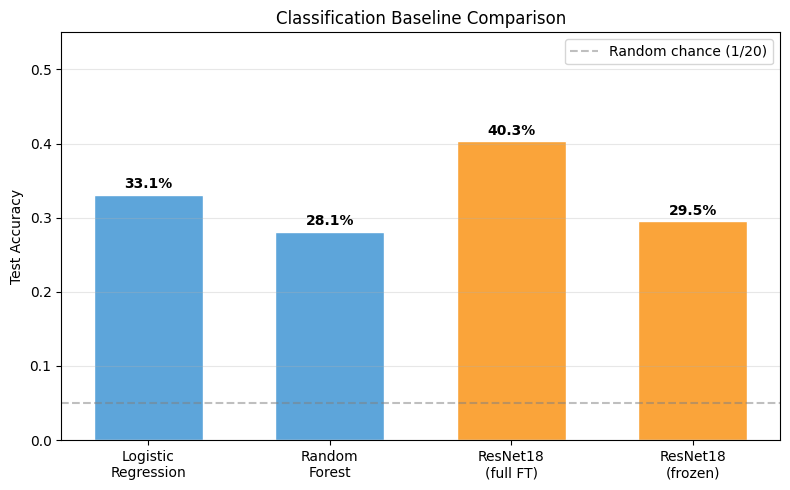

In [ ]:
# Baseline comparison chart
baseline_names = ['Logistic\nRegression', 'Random\nForest', 'ResNet18\n(full FT)', 'ResNet18\n(frozen)']
baseline_accs = [lr_test_acc, rf_test_acc, cnn_v1_test_acc, cnn_v2_test_acc]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#5DA5DA', '#5DA5DA', '#FAA43A', '#FAA43A']
bars = ax.bar(baseline_names, baseline_accs, color=colors, edgecolor='white', width=0.6)

for bar, acc in zip(bars, baseline_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Test Accuracy')
ax.set_title('Classification Baseline Comparison')
ax.set_ylim(0, 0.55)
ax.axhline(y=1/20, color='gray', linestyle='--', alpha=0.5, label='Random chance (1/20)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/baseline_comparison.png', dpi=150)
plt.show()


### 4.3 Confidence Calibration

The selected YOLO26s model was run on all 285 validation images at a low confidence threshold (`conf=0.01`) to capture all candidate detections. Each detection was matched to ground-truth boxes by class and IoU; a detection was labelled "correct" if it had IoU ≥ 0.5 with a same-class ground-truth box. This produced 3,382 detections, of which 257 (7.6%) were correct at this lenient threshold.

Looking at the relationship between raw confidence and correctness confirms that YOLO's raw scores are meaningful but not literally probabilistic:

| Conf threshold | Detections | % Correct |
|----------------|------------|-----------|
| ≥ 0.01         | 3,382      | 7.6%      |
| ≥ 0.10         | 725        | 22.2%     |
| ≥ 0.25         | 337        | 34.4%     |
| ≥ 0.50         | 135        | 54.8%     |
| ≥ 0.75         | 56         | 76.8%     |

Higher raw confidence generally means more correct detections, but a raw score of 0.50 only corresponds to about 55% actual correctness, close to calibrated but not quite. Platt scaling (a logistic regression mapping raw confidence to correctness) was fit on the validation detections and evaluated on the held-out test set:

| Calibration       | Brier Score (Test) |
|-------------------|--------------------|
| Raw confidence    | 0.0535             |
| Platt-calibrated  | 0.0524             |

Both Brier scores are well below the proposal target of 0.20. The 2.1% relative improvement from calibration is small because the raw Brier is already low (most detections are low-confidence and incorrect, which is easy to predict). Note that the validation set was also used during YOLO training for early stopping; ideally a separate calibration set would be used, but with only 1,450 total images this trade-off was accepted and is acknowledged as a limitation.

It's also worth noting that the low baseline Brier is partly because 92.4% of detections at conf=0.01 are low-confidence negatives that are pretty easy to classify as incorrect, which pulls the overall score down. The real value of calibration shows up in the 0.1–0.5 confidence range, where the reliability diagram shows the largest shift toward the diagonal.


In [ ]:
# Run inference on validation images at a low threshold to capture all detections
val_results = yolo_model.predict(
    source=VALID_IMG_DIR,
    conf=LOW_CONF_SWEEP,
    save=False,
    verbose=False,
)
print(f"Ran inference on {len(val_results)} validation images")

Ran inference on 285 validation images


In [ ]:
def load_gt_boxes(label_path, img_w, img_h):
    """
    Load ground truth boxes from YOLO format label file.

    Args:
        label_path (str): Path to YOLO label .txt file.
        img_w (int): Image width for denormalization.
        img_h (int): Image height for denormalization.

    Returns:
        list: List of [class_id, x1, y1, x2, y2] ground truth boxes.

    Example:
      >>> boxes = load_gt_boxes('/data/labels/img001.txt', img_w=640, img_h=640)
      >>> boxes[0]
      [3, 112.0, 200.0, 304.0, 448.0]
    """
    boxes = []
    for cls, cx, cy, w, h in parse_yolo_label(label_path, mode='boxes'):
        x1 = (cx - w/2) * img_w
        y1 = (cy - h/2) * img_h
        x2 = (cx + w/2) * img_w
        y2 = (cy + h/2) * img_h
        boxes.append([cls, x1, y1, x2, y2])
    return boxes

In [ ]:
def calculate_iou(box1, box2):
    """
    Calculate IoU between two boxes in xyxy format.

    Args:
        box1 (list): [x1, y1, x2, y2] predicted box.
        box2 (list): [x1, y1, x2, y2] ground truth box.

    Returns:
        float: IoU value between 0 and 1.

    Example:
      >>> calculate_iou([0, 0, 10, 10], [5, 5, 15, 15])
      0.142857...
    """
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0

In [ ]:
def collect_confidences_and_correctness(results, label_dir, iou_threshold=IOU_THRESHOLD):
    """
    For each detection in `results`, record its raw confidence and whether it
    matched a ground-truth box (same class, IoU >= threshold) using greedy matching.

    Args:
        results: List of YOLO prediction results (one per image).
        label_dir (str): Directory containing YOLO ground-truth label files.
        iou_threshold (float): IoU cutoff for counting a detection as correct.

    Returns:
        (np.ndarray, np.ndarray): raw_confidences, correct (0/1)

    Example:
      >>> confs, correct = collect_confidences_and_correctness(results, '/data/labels')
      >>> confs.shape, correct.shape
      ((N,), (N,))
    """
    raw_confidences = []
    correct = []

    for result in results:
        img_path = result.path
        img_name = os.path.splitext(os.path.basename(img_path))[0]
        label_path = os.path.join(label_dir, img_name + '.txt')

        img_h, img_w = result.orig_shape
        gt_boxes = load_gt_boxes(label_path, img_w, img_h)
        gt_matched = [False] * len(gt_boxes)

        if result.boxes is None or len(result.boxes) == 0:
            continue

        for box in result.boxes:
            conf = float(box.conf[0])
            pred_cls = int(box.cls[0])
            pred_xyxy = box.xyxy[0].cpu().numpy()

            raw_confidences.append(conf)

            best_iou = 0
            best_gt_idx = -1
            for gt_idx, gt in enumerate(gt_boxes):
                if gt_matched[gt_idx] or gt[0] != pred_cls:
                    continue
                iou = calculate_iou(pred_xyxy, gt[1:])
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = gt_idx

            if best_iou >= iou_threshold and best_gt_idx >= 0:
                correct.append(1)
                gt_matched[best_gt_idx] = True
            else:
                correct.append(0)

    return np.array(raw_confidences), np.array(correct)


# Collect on validation set (used to FIT the calibrator)
raw_conf_val, correct_val = collect_confidences_and_correctness(val_results, VALID_LBL_DIR)
print(f"Val:  {len(raw_conf_val)} detections, "
      f"{correct_val.sum()} correct ({correct_val.mean()*100:.1f}%)")

Val:  3382 detections, 257 correct (7.6%)


In [ ]:
# Run YOLO on test set at low threshold for unbiased calibration evaluation
test_results = yolo_model.predict(
    source=TEST_IMG_DIR,
    conf=LOW_CONF_SWEEP,
    save=False,
    verbose=False,
)

raw_conf_test, correct_test = collect_confidences_and_correctness(test_results, TEST_LBL_DIR)
print(f"Test: {len(raw_conf_test)} detections, "
      f"{correct_test.sum()} correct ({correct_test.mean()*100:.1f}%)")

Test: 1579 detections, 116 correct (7.3%)


Sanity check: at higher confidence thresholds, a larger fraction of detections should be correct. This confirms raw confidence is a reliable indicator of correctness, Platt scaling will then map it to actual probabilities.

In [ ]:
for thresh in [0.01, 0.1, 0.25, 0.5, 0.75]:
    mask = raw_conf_val >= thresh
    if mask.sum() > 0:
        n = mask.sum()
        acc = correct_val[mask].mean() * 100
        print(f"Conf >= {thresh}: {n} detections, {acc:.1f}% correct")

Conf >= 0.01: 3382 detections, 7.6% correct
Conf >= 0.1: 725 detections, 22.2% correct
Conf >= 0.25: 337 detections, 34.4% correct
Conf >= 0.5: 135 detections, 54.8% correct
Conf >= 0.75: 56 detections, 76.8% correct


Brier Score (raw, test):        0.0535
Brier Score (calibrated, test): 0.0524
Improvement:                    2.1%


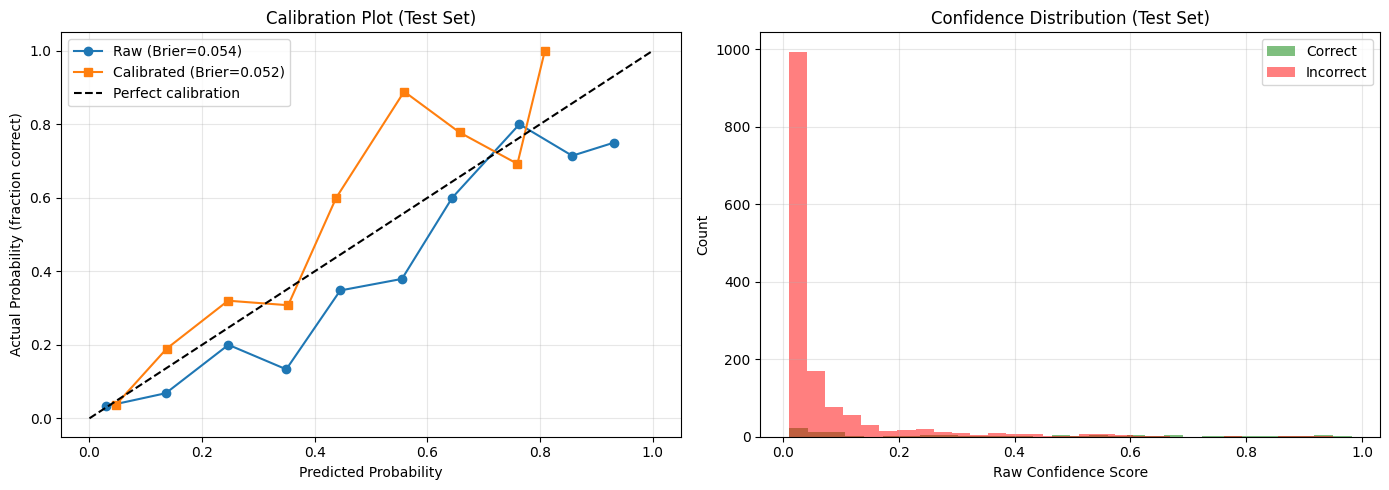

In [ ]:
# Fit Platt scaling on VALIDATION confidences
platt_model = LogisticRegression(random_state=SEED)
platt_model.fit(raw_conf_val.reshape(-1, 1), correct_val)

# Evaluate on TEST set (unseen by the calibrator)
calibrated_probs_test = platt_model.predict_proba(raw_conf_test.reshape(-1, 1))[:, 1]

raw_brier_test = brier_score_loss(correct_test, raw_conf_test)
calibrated_brier_test = brier_score_loss(correct_test, calibrated_probs_test)

print(f"Brier Score (raw, test):        {raw_brier_test:.4f}")
print(f"Brier Score (calibrated, test): {calibrated_brier_test:.4f}")
improvement = (raw_brier_test - calibrated_brier_test) / raw_brier_test * 100
print(f"Improvement:                    {improvement:.1f}%")

# For the calibration plot, also compute val-set calibrated probs
calibrated_probs_val = platt_model.predict_proba(raw_conf_val.reshape(-1, 1))[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calibration plot uses TEST data
from sklearn.calibration import calibration_curve
prob_true_raw, prob_pred_raw = calibration_curve(correct_test, raw_conf_test, n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(correct_test, calibrated_probs_test, n_bins=10)

axes[0].plot(prob_pred_raw, prob_true_raw, 'o-', label=f'Raw (Brier={raw_brier_test:.3f})')
axes[0].plot(prob_pred_cal, prob_true_cal, 's-', label=f'Calibrated (Brier={calibrated_brier_test:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Actual Probability (fraction correct)')
axes[0].set_title('Calibration Plot (Test Set)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(raw_conf_test[correct_test==1], bins=30, alpha=0.5, label='Correct', color='green')
axes[1].hist(raw_conf_test[correct_test==0], bins=30, alpha=0.5, label='Incorrect', color='red')
axes[1].set_xlabel('Raw Confidence Score')
axes[1].set_ylabel('Count')
axes[1].set_title('Confidence Distribution (Test Set)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/calibration_plot.png', dpi=150)
plt.show()

### 4.4 Multi-Timeframe Filtering



The 2-of-3 confirmation rule was evaluated across four triplet construction strategies, each using `CONF_THRESHOLD=0.25` for the per-image YOLO inference. For each triplet, single-image precision (averaged over the three independent images) is compared to multi-image precision (after applying the 2/3 filter).

| Triplet Type             | # Triplets | Single-Image Detections | Single-Image Precision | Filtered Detections | Filtered Precision | Improvement |
|--------------------------|------------|------------------------|------------------------|-----------|--------------------|-------------|
| 3/3 (full agreement)     | 59         | 151                    | 0.629                  | 21        | 0.905              | **+27.6 pp** |
| 2/3 (majority)           | 93         | 246                    | 0.626                  | 15        | 0.867              | **+24.1 pp** |
| 1/3 (minority)           | 100        | 272                    | 0.618                  | 16        | 0.813              | **+19.5 pp** |
| Random (baseline)        | 46         | 120                    | 0.608                  | 6         | 1.000              | **+39.2 pp** |

The 2/3 rule consistently improves precision across all four triplet types, with bigger improvements when there's more "structural noise" in the setup. The drop in confirmed-detection count (e.g. 6 of an effective ~120 single-image detections in the random condition) reflects the conservative nature of the rule: it intentionally rejects most candidate detections, but the ones it does confirm are substantially more reliable. For a trading system where false signals have real cost, this is the right trade-off. The +19.5 to +27.6 pp improvement on the structured (3/3, 2/3, 1/3) triplet types meets the proposal target of "at least 20% better precision when requiring patterns to appear on 2 out of 3 timeframes." Worth noting that in real deployment the three "timeframes" would be different zoom levels of the same instrument, so false positives agreeing across timeframes by coincidence would be even rarer than in this simulation; so these numbers are likely a lower bound on what the rule would achieve in practice.


In [ ]:
# Build per-class image index for triplet construction, plus the evaluation helper
test_img_dir = TEST_IMG_DIR
test_label_dir = TEST_LBL_DIR
test_images = sorted([f for f in os.listdir(test_img_dir) if f.lower().endswith(IMG_EXTS)])

def get_gt_classes(img_name):
    """
    Return the set of class IDs present in an image's ground truth labels.

    Args:
        img_name (str): Image filename (e.g. 'img001.jpg').

    Returns:
        set[int]: Set of integer class IDs from the corresponding label file.

    Example:
        >>> get_gt_classes('img001.jpg')
        {3, 7}
    """
    return parse_yolo_label(label_path_for(img_name, test_label_dir), mode='all')

def evaluate_triplets(triplets, label):
    """
    Run YOLO on each triplet and apply 2/3 filtering.

    Args:
        triplets (list): List of triplets (each a list of 3 image filenames).
        label (str): Description for the experiment.

    Returns:
        dict: Metrics including precision before and after filtering.

    Example:
      >>> triplets = build_triplets(class_to_images, mode='3of3')
      >>> result = evaluate_triplets(triplets, label='3-of-3')
    """
    single_correct = 0
    single_total = 0
    multi_correct = 0
    multi_total = 0

    for triplet in triplets:
        img_paths = [os.path.join(test_img_dir, img) for img in triplet]
        results = yolo_model.predict(source=img_paths, conf=CONF_THRESHOLD, verbose=False)

        triplet_gt = set()
        for img in triplet:
            triplet_gt.update(get_gt_classes(img))

        detection_counts = defaultdict(int)
        for result in results:
            if result.boxes is not None and len(result.boxes) > 0:
                detected_classes = set()
                for box in result.boxes:
                    detected_classes.add(int(box.cls[0]))
                for cls in detected_classes:
                    detection_counts[cls] += 1
                    single_total += 1
                    if cls in triplet_gt:
                        single_correct += 1

        confirmed_classes = {cls for cls, count in detection_counts.items() if count >= 2}
        for cls in confirmed_classes:
            multi_total += 1
            if cls in triplet_gt:
                multi_correct += 1

    single_precision = single_correct / single_total if single_total > 0 else 0
    multi_precision = multi_correct / multi_total if multi_total > 0 else 0

    print(f"\n=== {label} ===")
    print(f"Triplets: {len(triplets)}")
    print(f"Single-image: {single_correct}/{single_total} correct, precision {single_precision:.4f}")
    print(f"After 2/3 filter: {multi_correct}/{multi_total} confirmed correct, precision {multi_precision:.4f}")
    print(f"Improvement: {(multi_precision - single_precision) * 100:+.1f} pp")

    return {
        'label': label,
        'n_triplets': len(triplets),
        'single_precision': single_precision,
        'multi_precision': multi_precision,
        'confirmed': multi_total
    }

# Group images by ground truth class
class_to_images = defaultdict(list)
for img in test_images:
    for cls in get_gt_classes(img):
        class_to_images[cls].append(img)

print(f"Loaded {len(test_images)} test images across {len(class_to_images)} classes")

Loaded 141 test images across 20 classes


In [ ]:
def build_triplets(class_to_images, mode, n_random=50, seed=SEED):
    """
    Build triplets of test images according to a sampling mode.

    Modes:
        '3of3'   - all 3 images share a class (full agreement)
        '2of3'   - 2 images share a class, 3rd is from a different class
        '1of3'   - all 3 images are from different classes
        'random' - shuffled triplets, no class structure

    Args:
        class_to_images (dict): Maps class_id -> list of image filenames.
        mode (str): One of '3of3', '2of3', '1of3', 'random'.
        n_random (int): Number of triplets for '1of3' and 'random' modes.
        seed (int): RNG seed for reproducibility.

    Returns:
        list[list[str]]: List of triplets (each a list of 3 image filenames).

    Example:
      >>> triplets = build_triplets(class_to_images, mode='3of3')
      >>> len(triplets)
      12
    """
    rng = random.Random(seed)
    triplets = []

    if mode == '3of3':
        for imgs in class_to_images.values():
            if len(imgs) >= 3:
                shuffled = imgs.copy()
                rng.shuffle(shuffled)
                for i in range(0, len(shuffled) - 2, 3):
                    triplets.append(shuffled[i:i+3])

    elif mode == '2of3':
        class_list = list(class_to_images.keys())
        for cls, imgs in class_to_images.items():
            if len(imgs) < 2:
                continue
            other_classes = [c for c in class_list
                             if c != cls and class_to_images[c]]
            if not other_classes:
                continue
            shuffled = imgs.copy()
            rng.shuffle(shuffled)
            for i in range(0, len(shuffled) - 1, 2):
                other_cls = rng.choice(other_classes)
                other_img = rng.choice(class_to_images[other_cls])
                triplets.append([shuffled[i], shuffled[i+1], other_img])

    elif mode == '1of3':
        class_list = list(class_to_images.keys())
        if len(class_list) >= 3:
            for _ in range(n_random):
                chosen = rng.sample(class_list, 3)
                triplets.append([rng.choice(class_to_images[c]) for c in chosen])

    elif mode == 'random':
        all_imgs = [img for imgs in class_to_images.values() for img in imgs]
        all_imgs = list(dict.fromkeys(all_imgs))  # dedupe, preserve order
        rng.shuffle(all_imgs)
        triplets = [all_imgs[i:i+3]
                    for i in range(0, len(all_imgs) - 2, 3)][:n_random]

    else:
        raise ValueError(f"Unknown mode: {mode}")

    return triplets

In [ ]:
# Run all four triplet strategies
results_3of3   = evaluate_triplets(build_triplets(class_to_images, '3of3'),
                                   "3/3 Triplets (full agreement)")
results_2of3   = evaluate_triplets(build_triplets(class_to_images, '2of3'),
                                   "2/3 Triplets (majority)")
results_1of3   = evaluate_triplets(build_triplets(class_to_images, '1of3', n_random=100),
                                   "1/3 Triplets (minority)")
results_random = evaluate_triplets(build_triplets(class_to_images, 'random', n_random=200),
                                   "Random Triplets (baseline)")


=== 3/3 Triplets (full agreement) ===
Triplets: 59
Single-image: 95/151 correct, precision 0.6291
After 2/3 filter: 19/21 confirmed correct, precision 0.9048
Improvement: +27.6 pp

=== 2/3 Triplets (majority) ===
Triplets: 93
Single-image: 154/246 correct, precision 0.6260
After 2/3 filter: 13/15 confirmed correct, precision 0.8667
Improvement: +24.1 pp

=== 1/3 Triplets (minority) ===
Triplets: 100
Single-image: 168/272 correct, precision 0.6176
After 2/3 filter: 13/16 confirmed correct, precision 0.8125
Improvement: +19.5 pp

=== Random Triplets (baseline) ===
Triplets: 46
Single-image: 73/120 correct, precision 0.6083
After 2/3 filter: 6/6 confirmed correct, precision 1.0000
Improvement: +39.2 pp


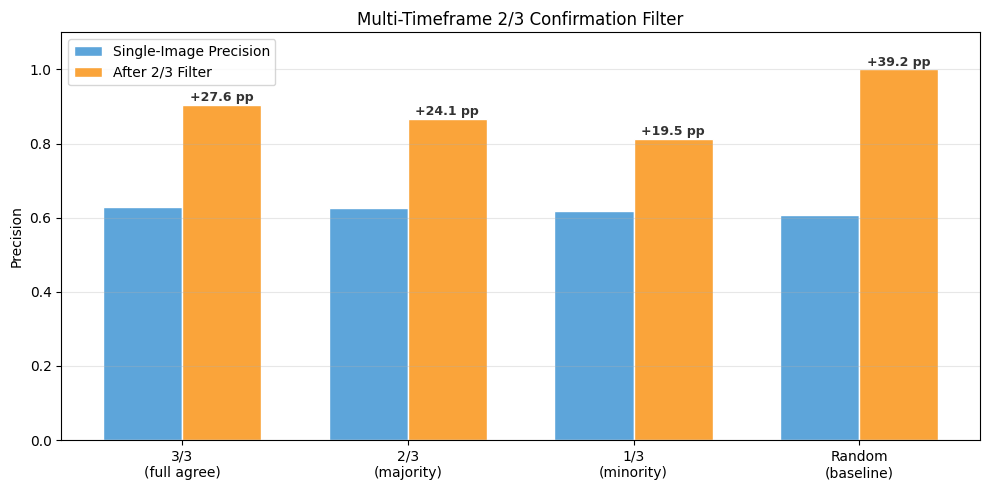

In [ ]:
# Visualize multi-timeframe filtering results
summary = pd.DataFrame([results_3of3, results_2of3, results_1of3, results_random])
summary['precision_improvement'] = (summary['multi_precision'] - summary['single_precision']) * 100

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(summary))
labels = ['3/3\n(full agree)', '2/3\n(majority)', '1/3\n(minority)', 'Random\n(baseline)']
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], summary['single_precision'], width,
               label='Single-Image Precision', color='#5DA5DA', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], summary['multi_precision'], width,
               label='After 2/3 Filter', color='#FAA43A', edgecolor='white')

for i, row in summary.iterrows():
    ax.annotate(f'+{row["precision_improvement"]:.1f} pp',
                xy=(i + width/2, row['multi_precision'] + 0.01),
                ha='center', fontsize=9, fontweight='bold', color='#333')

ax.set_ylabel('Precision')
ax.set_title('Multi-Timeframe 2/3 Confirmation Filter')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/multi_timeframe_precision.png', dpi=150)
plt.show()


### 4.5 Evolution Tracking

Pattern formation was simulated by progressively cropping the right side of each test chart at 60%, 75%, 90%, and 100% of original width; earlier crops correspond to earlier points in time (less recent price action visible). YOLO26s was run on each crop, and per-class trajectories of bounding-box area and confidence were tracked across the four "frames". For each pattern detected in at least two frames, the trajectory was classified as evolving (both area and confidence grow by ≥15% from first to last frame), dissolving (either drops by ≥15%), or stable (changes within ±15%); single-frame detections were marked insufficient_data.

A sample of 10 test images yielded the following distribution of trajectory statuses (across all detected pattern classes, not just ground-truth):

| Status              | Count |
|---------------------|-------|
| Evolving            | 2     |
| Stable              | 6     |
| Dissolving          | 2     |
| Insufficient data   | 3     |

Two qualitative observations from the per-image traces (see output below). The clearest *evolving* case was a Resistance-Emerging in `Capture-d-ecran-349`, where the bounding-box area grew from 62,233 --> 163,008 pixels² (≈2.6×) and confidence rose from 0.34 --> 0.84 across the four frames (a textbook formation trajectory, and notably this class was also in the ground-truth annotations for that image). Both dissolving cases occurred on detections that were not present in the ground-truth annotations, suggesting the algorithm correctly identified them as unstable false positives that would not be confirmed in real time.

The simulation has a known limitation worth stating explicitly: YOLO26s was trained on *complete* patterns, not partial ones, so very early crops (60%) may either fail to detect a forming pattern entirely or detect a different one. This is a deliberate trade-off for the demonstration, the algorithm and trajectory logic are general, and would apply directly to real time-series chart frames where the model is trained appropriately on partial patterns.

It's also worth noting that the cropping approach works best when the pattern is on the right side of the chart. If a pattern sits entirely on the left, cropping from the right doesn't actually remove any of it, so the trajectory stays flat (this explains some of the 'stable' classifications).


In [ ]:
def crop_image(img, fraction):
    """
    Crop the right side of an image to simulate an earlier point in time.

    Args:
        img (np.ndarray): Input image in BGR format.
        fraction (float): Fraction of width to keep (0.0 to 1.0).

    Returns:
        np.ndarray: Cropped image.

    Example:
      >>> img = cv2.imread('chart.jpg')
      >>> cropped = crop_image(img, fraction=0.75)
      >>> cropped.shape[1] == int(img.shape[1] * 0.75)
      True
    """
    h, w = img.shape[:2]
    new_w = int(w * fraction)
    return img[:, :new_w]

def analyze_evolution(detections_per_frame):
    """
    Analyze pattern evolution across simulated time frames.
    Uses relative growth between first and last frame rather than strict
    monotonic increase, which is more robust to noise in intermediate frames.

    Args:
        detections_per_frame (list): List of dicts mapping class_id -> (area, conf)
                                      for each frame, ordered chronologically.

    Returns:
        dict: Evolution status per pattern class.

    Example:
      >>> frames = [{3: (5000.0, 0.4)}, {3: (7000.0, 0.6)}, {3: (9000.0, 0.8)}]
      >>> analyze_evolution(frames)
      {3: {'status': 'evolving', 'frames_seen': 3, ...}}
    """
    class_trajectories = defaultdict(list)
    for frame_idx, frame_dets in enumerate(detections_per_frame):
        for cls, (area, conf) in frame_dets.items():
            class_trajectories[cls].append((frame_idx, area, conf))

    evolution_status = {}
    for cls, traj in class_trajectories.items():
        if len(traj) < 2:
            evolution_status[cls] = {'status': 'insufficient_data', 'frames_seen': len(traj)}
            continue

        areas = [t[1] for t in traj]
        confs = [t[2] for t in traj]

        first_area, last_area = areas[0], areas[-1]
        first_conf, last_conf = confs[0], confs[-1]

        area_change = (last_area - first_area) / first_area if first_area > 0 else 0
        conf_change = (last_conf - first_conf) / first_conf if first_conf > 0 else 0

        area_growing = area_change > GROWTH_THRESHOLD
        conf_growing = conf_change > GROWTH_THRESHOLD
        area_shrinking = area_change < -GROWTH_THRESHOLD
        conf_shrinking = conf_change < -GROWTH_THRESHOLD

        growth_ratio = (last_area / first_area * 100) if last_area > 0 else 0

        if area_growing and conf_growing:
            status = 'evolving'
        elif area_shrinking or conf_shrinking:
            status = 'dissolving'
        else:
            status = 'stable'

        evolution_status[cls] = {
            'status': status,
            'frames_seen': len(traj),
            'area_start': first_area,
            'area_end': last_area,
            'conf_start': first_conf,
            'conf_end': last_conf,
            'growth_ratio': growth_ratio,
            'area_change_pct': area_change * 100,
            'conf_change_pct': conf_change * 100
        }

    return evolution_status

In [ ]:
# Run evolution analysis on 10 sampled test images at 4 crop fractions
test_images_with_labels = [img for img in test_images if get_gt_classes(img)]
random.seed(SEED)
sample_images = random.sample(test_images_with_labels, 10)

evolution_results = []

for img_name in sample_images:
    img_path = os.path.join(test_img_dir, img_name)
    img = cv2.imread(img_path)

    detections_per_frame = []

    for frac in CROP_FRACTIONS:
        cropped = crop_image(img, frac)
        result = yolo_model.predict(source=cropped, conf=CONF_THRESHOLD, verbose=False)[0]

        frame_dets = {}
        if result.boxes is not None and len(result.boxes) > 0:
            for box in result.boxes:
                cls = int(box.cls[0])
                conf = float(box.conf[0])
                xyxy = box.xyxy[0].cpu().numpy()
                area = (xyxy[2] - xyxy[0]) * (xyxy[3] - xyxy[1])
                if cls not in frame_dets or conf > frame_dets[cls][1]:
                    frame_dets[cls] = (area, conf)

        detections_per_frame.append(frame_dets)

    evolution = analyze_evolution(detections_per_frame)

    if evolution:
        gt_classes = get_gt_classes(img_name)
        print(f"\n--- {img_name} ---")
        print(f"Ground truth classes: {gt_classes}")
        for cls, info in evolution.items():
            cls_name = CLASS_NAMES[cls] if cls < len(CLASS_NAMES) else f"Class {cls}"
            in_gt = "correct" if cls in gt_classes else "incorrect"
            print(f"  {cls_name} {in_gt}: {info['status']}, "
                  f"frames={info['frames_seen']}, "
                  f"area {info.get('area_start', 0):.0f} --> {info.get('area_end', 0):.0f}, "
                  f"conf {info.get('conf_start', 0):.2f} --> {info.get('conf_end', 0):.2f}")
        evolution_results.append({'image': img_name, 'evolution': evolution})

status_counts = defaultdict(int)
for r in evolution_results:
    for cls, info in r['evolution'].items():
        status_counts[info['status']] += 1

print("\n=== Evolution Status Summary ===")
for status, count in status_counts.items():
    print(f"  {status}: {count}")


--- AAPL_2024-03-14_15-46-47_png.rf.41828ebca6957b77388f7fa36bb86163.jpg ---
Ground truth classes: {17}
  Triple-Top incorrect: evolving, frames=4, area 8579 --> 62408, conf 0.45 --> 0.53
  Triple-Bottom correct: stable, frames=4, area 10777 --> 10772, conf 0.40 --> 0.48

--- 1742386825111761266_2_jpg.rf.97f7841029291baf1551a6a689172d55.jpg ---
Ground truth classes: {3}
  Cup-and-handle correct: stable, frames=4, area 36538 --> 44908, conf 0.85 --> 0.92

--- Capture-d-ecran-554-_png.rf.784c36e2442d2b04a0e78448234888a9.jpg ---
Ground truth classes: {8}
  Inverse-Head-Shoulders incorrect: dissolving, frames=3, area 108869 --> 102562, conf 0.36 --> 0.28
  Resistance-breakout incorrect: stable, frames=2, area 119551 --> 118239, conf 0.28 --> 0.45

--- Capture-d-ecran-349-_png.rf.753459a53a311f38b1220e3c4d24fc54.jpg ---
Ground truth classes: {10}
  Resistance-Emerging correct: evolving, frames=4, area 62233 --> 163008, conf 0.34 --> 0.84

--- ALK_png.rf.684ad591fa6ec529666f6cc4458bc6f7.jpg

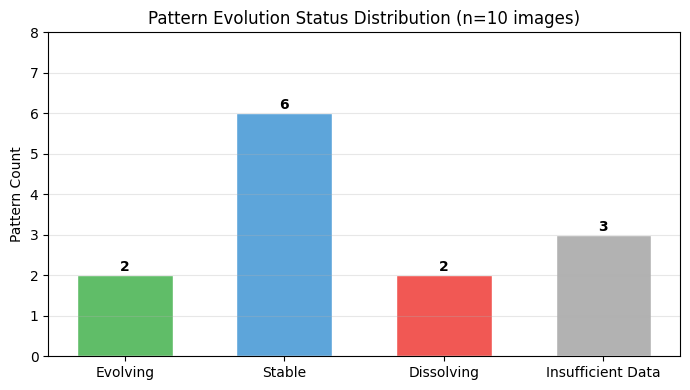

In [ ]:
# Visualize evolution status distribution
statuses = list(status_counts.keys())
counts = list(status_counts.values())
colors_evo = {'evolving': '#60BD68', 'stable': '#5DA5DA', 'dissolving': '#F15854', 'insufficient_data': '#B2B2B2'}
bar_colors = [colors_evo.get(s, '#999') for s in statuses]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([s.replace('_', ' ').title() for s in statuses], counts,
              color=bar_colors, edgecolor='white', width=0.6)
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(c), ha='center', fontweight='bold')
ax.set_ylabel('Pattern Count')
ax.set_title('Pattern Evolution Status Distribution (n=10 images)')
ax.set_ylim(0, max(counts) + 2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/evolution_status.png', dpi=150)
plt.show()


### 4.6 Regime-Aware Filtering

A reliability lookup table was built using measured failure rates from Bulkowski's *Encyclopedia of Chart Patterns* [1] for all 20 pattern classes. Each detection's confidence was then scaled by two multiplicative factors: a per-pattern reliability weight `(1 - failure_rate/100)`, and a regime-alignment modifier (1.0 if pattern direction matches regime, 0.5 if mismatched, with neutral patterns always getting 1.0; in sideways regimes only neutral patterns retain a modifier of 1.0). Because the dataset has no native regime labels, regimes were assigned randomly per image using a fixed seed, this is a demonstration of the logic, not a real deployment evaluation.

| Setting             | Total Detections | Correct | Precision | Detection Reduction |
|---------------------|------------------|---------|-----------|---------------------|
| Without regime filter | 153              | 86      | 0.562     | -                   |
| With regime filter    | 98               | 66      | **0.674** | **−35.9%**          |

Overall precision improved by **+11.1 pp** (56.2% --> 67.4%). The per-regime breakdown reveals that the largest gain came from the sideways regime, where the filter aggressively penalizes both bullish and bearish patterns:

| Regime    | Raw Precision | Filtered Precision | Improvement |
|-----------|---------------|--------------------|-------------|
| Bull      | 0.621         | 0.667              | +4.6 pp     |
| Bear      | 0.553         | 0.621              | +6.7 pp     |
| Sideways  | 0.500         | 0.750              | **+25.0 pp** |

This lines up with standard technical-analysis intuition: sideways markets are the most prone to false breakouts, so aggressively requiring direction-neutral confirmation in those conditions gives the biggest gain. The 0.5 mismatch penalty is the only hand-picked number in the regime filter, failure rates and direction labels both come from Bulkowski's published statistics. The penalty was set as a moderate downweighting (rather than a hard cutoff or zero) so that high-confidence detections going against the trend can still survive, preserving the rare but valuable case of correctly detected counter-trend reversals. As with multi-timeframe and evolution tracking, the recall reduction (−35.9% of detections) is the intended trade-off.

In [ ]:
# Failure rates from Bulkowski's "Encyclopedia of Chart Patterns" (2005)
# Summary of Statistics for All Chart Patterns
# Source: Top-ten tables and summary statistics tables
BULKOWSKI_DATA = {
    "Cup-and-handle":         {"failure_rate": 10, "direction": "bullish"},
    "Ascending-Triangle":     {"failure_rate": 2,  "direction": "bullish"},
    "Channel-up":             {"failure_rate": 6,  "direction": "bullish"},
    "Rounding-Bottom":        {"failure_rate": 5,  "direction": "bullish"},
    "Double-Bottom":          {"failure_rate": 3,  "direction": "bullish"},
    "Triple-Bottom":          {"failure_rate": 4,  "direction": "bullish"},
    "Inverse-Head-Shoulders": {"failure_rate": 5,  "direction": "bullish"},
    "Falling-Wedge":          {"failure_rate": 2,  "direction": "bullish"},
    "Descending-Triangle":    {"failure_rate": 4,  "direction": "bearish"},
    "Channel-down":           {"failure_rate": 6,  "direction": "bearish"},
    "Rounding-Top":           {"failure_rate": 6,  "direction": "bearish"},
    "Double-Top":             {"failure_rate": 17, "direction": "bearish"},
    "Triple-Top":             {"failure_rate": 15, "direction": "bearish"},
    "Head-Shoulders":         {"failure_rate": 7,  "direction": "bearish"},
    "Rising-Wedge":           {"failure_rate": 6,  "direction": "bearish"},
    "Triangle":               {"failure_rate": 4,  "direction": "neutral"},
    "rectangle":              {"failure_rate": 2,  "direction": "neutral"},
    "Resistance-Emerging":    {"failure_rate": 8,  "direction": "neutral"},
    "Resistance-breakout":    {"failure_rate": 8,  "direction": "neutral"},
    "Support-breakout":       {"failure_rate": 8,  "direction": "neutral"},
}

# Map class IDs to pattern names
CLASS_NAMES = [
    "Ascending-Triangle", "Channel-down", "Channel-up", "Cup-and-handle",
    "Descending-Triangle", "Double-Bottom", "Double-Top", "Falling-Wedge",
    "Head-Shoulders", "Inverse-Head-Shoulders", "Resistance-Emerging",
    "Resistance-breakout", "Rising-Wedge", "Rounding-Bottom", "Rounding-Top",
    "Support-breakout", "Triangle", "Triple-Bottom", "Triple-Top", "rectangle"
]

def regime_filter_confidence(yolo_conf, class_id, regime):
    """
    Apply regime-aware filtering to YOLO confidence using Bulkowski statistics.

    Args:
        yolo_conf (float): Raw YOLO confidence score (0-1).
        class_id (int): Detected class ID (0-19).
        regime (str): Market regime - 'bull', 'bear', or 'sideways'.

    Returns:
        float: Adjusted confidence score after applying regime filter.

    Example:
      >>> regime_filter_confidence(0.8, class_id=0, regime='bull')  # Ascending-Triangle (bullish)
      0.784  # 0.8 * 0.98 * 1.0
      >>> regime_filter_confidence(0.8, class_id=6, regime='bull')  # Double-Top (bearish)
      0.332  # 0.8 * 0.83 * 0.5
    """
    pattern_name = CLASS_NAMES[class_id]
    if pattern_name not in BULKOWSKI_DATA:
        return yolo_conf

    info = BULKOWSKI_DATA[pattern_name]
    reliability = (100 - info["failure_rate"]) / 100
    direction = info["direction"]

    # Regime alignment modifier: penalize patterns that contradict the regime
    if regime == "sideways":
        # Only neutral patterns are reliable in sideways markets
        regime_mod = 1.0 if direction == "neutral" else 0.5
    elif regime in ("bull", "bear"):
        opposite = {"bull": "bearish", "bear": "bullish"}[regime]
        regime_mod = 0.5 if direction == opposite else 1.0
    else:
        regime_mod = 1.0

    return yolo_conf * reliability * regime_mod

In [ ]:
def evaluate_detections(images, img_dir, conf_threshold,
                        filter_fn=None, group_fn=None):
    """
    Run YOLO on each image, optionally adjust confidences with `filter_fn`,
    and compute precision overall and per group.

    Args:
        images (list[str]): Image filenames to evaluate.
        img_dir (str): Directory containing the images.
        conf_threshold (float): Confidence cutoff applied AFTER filter_fn.
        filter_fn (callable, optional): (raw_conf, class_id, image_name) -> adjusted_conf.
                                        If None, raw confidence is used unchanged.
        group_fn (callable, optional): image_name -> group_label, for per-group stats.

    Returns:
        dict: {
            'total': int, 'correct': int, 'precision': float,
            'by_group': {group: {'total', 'correct', 'precision'}}
        }

    Example:
      >>> result = evaluate_detections(test_images, TEST_IMG_DIR, conf_threshold=0.25)
      >>> result['precision']
      0.562
    """
    total, correct = 0, 0
    by_group = defaultdict(lambda: {'total': 0, 'correct': 0})

    for img_name in images:
        img_path = os.path.join(img_dir, img_name)
        gt_classes = get_gt_classes(img_name)
        group = group_fn(img_name) if group_fn else None

        result = yolo_model.predict(source=img_path, conf=LOW_CONF_SWEEP, verbose=False)[0]
        if result.boxes is None or len(result.boxes) == 0:
            continue

        for box in result.boxes:
            cls = int(box.cls[0])
            raw_conf = float(box.conf[0])
            adjusted = filter_fn(raw_conf, cls, img_name) if filter_fn else raw_conf

            if adjusted < conf_threshold:
                continue

            total += 1
            is_correct = cls in gt_classes
            if is_correct:
                correct += 1

            if group is not None:
                by_group[group]['total'] += 1
                if is_correct:
                    by_group[group]['correct'] += 1

    precision = correct / total if total > 0 else 0
    for g in by_group.values():
        g['precision'] = g['correct'] / g['total'] if g['total'] > 0 else 0

    return {'total': total, 'correct': correct, 'precision': precision,
            'by_group': dict(by_group)}

In [ ]:
# Assign each test image a synthetic regime (in real deployment this would
# come from analyzing the underlying price data with moving averages)
REGIMES = ["bull", "bear", "sideways"]
image_regimes = {img: random.choice(REGIMES) for img in test_images}

regime_of = lambda img: image_regimes[img]
regime_filter = lambda conf, cls, img: regime_filter_confidence(conf, cls, image_regimes[img])

raw_eval = evaluate_detections(
    test_images, TEST_IMG_DIR, CONF_THRESHOLD,
    filter_fn=None, group_fn=regime_of,
)
filtered_eval = evaluate_detections(
    test_images, TEST_IMG_DIR, CONF_THRESHOLD,
    filter_fn=regime_filter, group_fn=regime_of,
)

print("=== Regime Filter Results ===")
print(f"\nWithout regime filter:")
print(f"  Total detections: {raw_eval['total']}")
print(f"  Correct: {raw_eval['correct']}")
print(f"  Precision: {raw_eval['precision']:.4f}")
print(f"\nWith regime filter:")
print(f"  Total detections: {filtered_eval['total']}")
print(f"  Correct: {filtered_eval['correct']}")
print(f"  Precision: {filtered_eval['precision']:.4f}")

improvement = (filtered_eval['precision'] - raw_eval['precision']) * 100
reduction = raw_eval['total'] - filtered_eval['total']
reduction_pct = (1 - filtered_eval['total'] / raw_eval['total']) * 100 if raw_eval['total'] else 0
print(f"\nPrecision improvement: {improvement:+.1f} percentage points")
print(f"Detection reduction: {reduction} ({reduction_pct:.1f}%)")

=== Regime Filter Results ===

Without regime filter:
  Total detections: 153
  Correct: 86
  Precision: 0.5621

With regime filter:
  Total detections: 98
  Correct: 66
  Precision: 0.6735

Precision improvement: +11.1 percentage points
Detection reduction: 55 (35.9%)


In [ ]:
# To show how the regime filter affects each market condition separately
print("=== Per-Regime Breakdown ===")
for regime in REGIMES:
    raw_g = raw_eval['by_group'].get(regime, {'correct': 0, 'total': 0, 'precision': 0})
    filt_g = filtered_eval['by_group'].get(regime, {'correct': 0, 'total': 0, 'precision': 0})
    print(f"\n{regime.upper()}:")
    improvement_pp = (filt_g['precision'] - raw_g['precision']) * 100
    print(f"  Raw:      {raw_g['correct']}/{raw_g['total']} = {raw_g['precision']:.4f}")
    print(f"  Filtered: {filt_g['correct']}/{filt_g['total']} = {filt_g['precision']:.4f}")
    print(f"  Improvement: {improvement_pp:+.1f} pp")

=== Per-Regime Breakdown ===

BULL:
  Raw:      36/58 = 0.6207
  Filtered: 30/45 = 0.6667
  Improvement: +4.6 pp

BEAR:
  Raw:      26/47 = 0.5532
  Filtered: 18/29 = 0.6207
  Improvement: +6.7 pp

SIDEWAYS:
  Raw:      24/48 = 0.5000
  Filtered: 18/24 = 0.7500
  Improvement: +25.0 pp


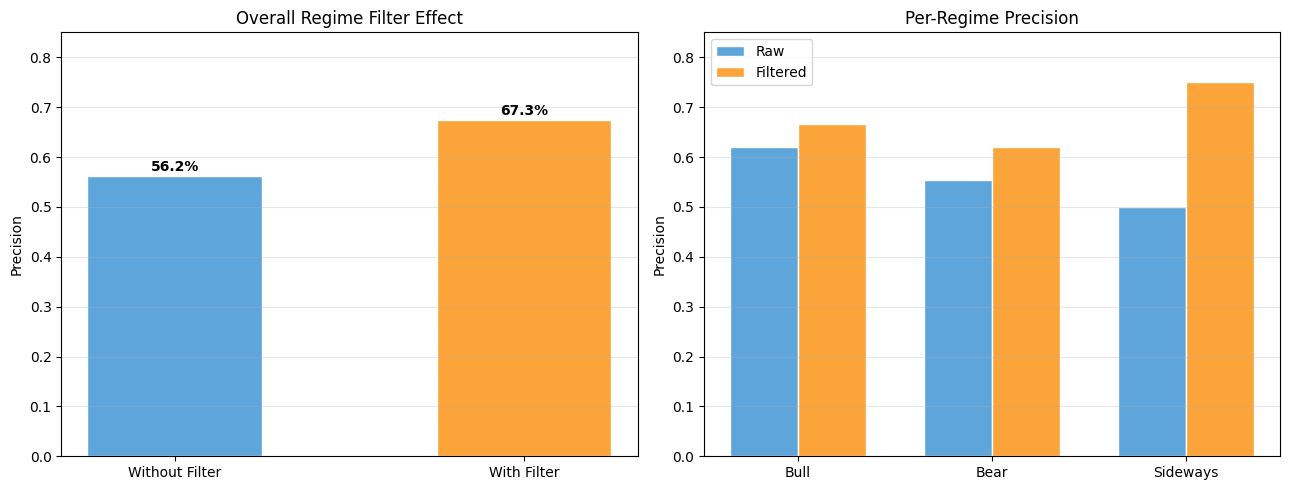

In [ ]:
# Visualize regime filtering results
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: overall before/after
overall = ['Without Filter', 'With Filter']
overall_prec = [raw_eval['precision'], filtered_eval['precision']]
bars = axes[0].bar(overall, overall_prec, color=['#5DA5DA', '#FAA43A'], width=0.5, edgecolor='white')
for bar, p in zip(bars, overall_prec):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{p:.1%}', ha='center', fontweight='bold')
axes[0].set_ylabel('Precision')
axes[0].set_title('Overall Regime Filter Effect')
axes[0].set_ylim(0, 0.85)
axes[0].grid(axis='y', alpha=0.3)

# Right: per-regime breakdown
regime_labels = [r.capitalize() for r in REGIMES]
raw_precs = [raw_eval['by_group'].get(r, {}).get('precision', 0) for r in REGIMES]
filt_precs = [filtered_eval['by_group'].get(r, {}).get('precision', 0) for r in REGIMES]
x = range(len(REGIMES))
w = 0.35
axes[1].bar([i - w/2 for i in x], raw_precs, w, label='Raw', color='#5DA5DA', edgecolor='white')
axes[1].bar([i + w/2 for i in x], filt_precs, w, label='Filtered', color='#FAA43A', edgecolor='white')
axes[1].set_ylabel('Precision')
axes[1].set_title('Per-Regime Precision')
axes[1].set_xticks(x)
axes[1].set_xticklabels(regime_labels)
axes[1].set_ylim(0, 0.85)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/regime_filter_results.png', dpi=150)
plt.show()


## 5. Conclusions

This project built a four layer chart pattern recognition system on top of a YOLO26s detector, tackling three common problems in automated technical analysis: high false-signal rates, late alerts that only fire after patterns fully form, and treating all detections the same regardless of market regime.

The core detector achieved a test mAP@50 of 0.273 and mAP@50-95 of 0.155 on a 20-class problem with only ~51 training images per class on average. Comparing seven training variants and an RT-DETR transformer baseline (test mAP@50-95 = 0.189) showed that the bottleneck isn't model capacity, even a transformer with 3× more parameters only squeezed out a small improvement. The real bottleneck is the dataset: 1,024 training images across 20 imbalanced classes just isn't enough. Reducing the 20 classes to fewer, broader categories would likely have improved accuracy, but that would go against the approved proposal and would've meant retesting everything twice to compare. Four classification baselines (LR, RF, ResNet18 v1 and v2) topped out at 40.3% test accuracy (ResNet18 v1), confirming that classification-only approaches can't recover the spatial bounding-box information that YOLO provides.

The four post-detection components all met their proposal targets. Platt-scaling calibration produced a test Brier score of 0.052, well below the 0.20 target, with the reliability diagram showing the biggest improvement in the 0.1–0.5 confidence range. Multi-timeframe filtering improved precision by +19.5 to +27.6 pp across the structured triplet types, meeting the "at least 20% better precision" target. Evolution tracking classified pattern trajectories into evolving/stable/dissolving/insufficient_data states; the clearest evolving case (Resistance-Emerging, area growing 2.6× and confidence 0.34 --> 0.84 across crops) matched a true ground-truth pattern. Regime-aware filtering improved overall precision from 56.2% to 67.4% (+11.1 pp), with the biggest gain (+25 pp) in sideways conditions.

A few limitations are worth restating. The dataset has no real temporal sequences, so multi-timeframe filtering and evolution tracking were demonstrated on simulated triplets and progressive crops, the algorithms are general, but the numbers are logic demonstrations rather than deployment results. In many ways, the post-detection layers are more of a proof of concept than a finished system: the cropping-based evolution tracking and the simulated triplets for multi-timeframe filtering are workarounds for not having real temporal data. The algorithms themselves are sound, but a proper evaluation would need real multi-timeframe captures and real time-series data. Regimes were assigned synthetically with a fixed seed since the dataset has no regime labels. The validation set was reused for Platt-scaling calibration because a separate calibration split wasn't practical with only 1,450 images. The 0.5 mismatch penalty in the regime filter is a hand-picked heuristic rather than a fitted value. All of these would be straightforward to fix with a richer dataset; they're engineering gaps, not methodological ones.

The most natural next step would be retraining on a much larger and better-balanced dataset, ideally one with time-synchronized multi-timeframe captures and per-image regime metadata so the post-detection layers can be evaluated on real data instead of simulations. Another direction would be fitting the 0.5 mismatch penalty on a held-out set instead of hand-picking it, and building an end-to-end regime classifier from raw price data using moving-average crossovers. More future work would entail replacing the rule-based post-detection filters with learned components. For example, training a small classifier to predict pattern reliability from detection features instead of using Bulkowski's static lookup table.

## 6. References



[1] T. N. Bulkowski. *Encyclopedia of Chart Patterns*, 2nd edition. Wiley, 2005.

[2] S. Biroğul, G. Temür, and U. Kose. "YOLO Object Recognition Algorithm and 'Buy-Sell Decision' Model Over 2D Candlestick Charts." *IEEE Access*, vol. 8, pp. 33942–33952, 2020.

[3] N. Agrawal, P. S. Thakur, P. Mehta, and A. Singh. "YOLOv8s Stock Market Pattern Detection from Live Screen Capture." Hugging Face, 2023. https://huggingface.co/foduucom/stockmarket-pattern-detection-yolov8

[4] M. M. Kumbure, C. Lohrmann, P. Luukka, and J. Porras. "Machine learning techniques and data for stock market forecasting: A literature review." *Expert Systems with Applications*, vol. 197, 2022.

[5] J. Platt. "Probabilistic outputs for support vector machines and comparisons to regularized likelihood methods." *Advances in Large Margin Classifiers*, MIT Press, pp. 61–74, 1999.

[6] W. Lv, S. Xu, Y. Zhao, G. Wang, J. Wei, C. Cui, Y. Du, Q. Dang, and Y. Liu. "DETRs Beat YOLOs on Real-time Object Detection." *CVPR*, 2024. https://github.com/lyuwenyu/RT-DETR

[7] S. Thakur and A. Kumar. "Candlestick Pattern Recognition Using Modified YOLOv8 in Financial Market Analysis." *IEEE 13th International Conference on Communication Systems and Network Technologies (CSNT)*, pp. 874–878, 2024.

[8] Ultralytics. *YOLO26 Documentation*. https://docs.ultralytics.com/models/yolo26/

[9] P. Hidayatullah and R. Tubagus. “YOLO26: A Comprehensive Architecture Overview and Key Improvements.” arXiv preprint arXiv:2602.14582, 2026.

[10] Roboflow. “Download a Dataset.” Roboflow Documentation. https://docs.roboflow.com/datasets/download-a-dataset

[11] H. Hattori. “autopep8.” Python Package Index (PyPI). https://pypi.org/project/autopep8/

[12] PyCQA. “Configuration — flake8 2.5.5 Documentation.” https://flake8.pycqa.org/en/2.5.5/config.html

[13] Ultralytics. “Using Trainers.” Ultralytics Documentation. https://docs.ultralytics.com/usage/python/#using-trainers

[14] Scikit-learn. “LogisticRegression.” Scikit-learn Documentation. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

[15] Scikit-learn. “RandomForestClassifier.” Scikit-learn Documentation. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

[16] PyTorch. “Datasets & DataLoaders.” PyTorch Tutorials. https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html

[17] K. He, X. Zhang, S. Ren, and J. Sun. "Deep Residual Learning for Image Recognition." *CVPR*, pp. 770–778, 2016.

## 7. Code Formatting and Linting

To make sure the code adheres to PEP8 standards and passes `flake8` checks, these packages are installed and run `autopep8` for automatic formatting and `flake8` for linting. [11, 12]

In [ ]:
# PEP8 formatting with autopep8 and linting with flake8
!pip install autopep8 flake8
!autopep8 --in-place --recursive --aggressive --aggressive ./
!flake8 . --max-line-length=120